# Multinomial Logistic Regression for Multi-Class MS Subtype Classification
## (RRMS, SPMS, PPMS)

---

**Research Objective:** Develop and evaluate a Multinomial Logistic Regression baseline model for classifying Multiple Sclerosis (MS) subtypes using structured clinical and MRI-derived features.

**Subtypes:**
- **RRMS** — Relapsing-Remitting MS
- **SPMS** — Secondary Progressive MS
- **PPMS** — Primary Progressive MS

---

## 1. Imports and Configuration

### Reproducibility and Deterministic Setup

Reproducibility is a cornerstone of rigorous scientific research. Setting a fixed random seed ensures that:

1. **Data splits** remain identical across runs, enabling fair comparison of models.
2. **Stochastic optimization** (e.g., solver initialization) produces consistent results.
3. **Third-party reviewers** can exactly replicate all reported metrics.

We suppress warnings to maintain clean notebook output and configure matplotlib for publication-quality figures with high-DPI rendering.

In [1]:
# ── Core Libraries ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# ── Scikit-learn Modules ──
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize

# ── Multicollinearity ──
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── Configuration ──
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')

# Publication-quality plot settings
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.figsize': (10, 6),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

CLASS_PALETTE = {'RRMS': '#2196F3', 'SPMS': '#FF5722', 'PPMS': '#4CAF50'}

print("Environment configured successfully.")
print(f"NumPy: {np.__version__}, Pandas: {pd.__version__}")
print(f"Random seed: {RANDOM_STATE}")

Environment configured successfully.
NumPy: 2.4.2, Pandas: 3.0.1
Random seed: 42


---
## 2. Data Loading and Initial Exploration

We load the dataset and perform a comprehensive initial inspection covering:
- **Shape and schema** — number of samples, features, and data types
- **Missing values** — identify features requiring imputation
- **Duplicates** — check for repeated observations that could bias training
- **Class distribution** — assess balance across MS subtypes

In [2]:
# Load dataset
df = pd.read_csv('../datasets/ms_dataset.csv')

print(f"Dataset shape: {df.shape[0]} samples × {df.shape[1]} features")
print("\n" + "="*60)
print("First 5 rows:")
df.head()

Dataset shape: 525 samples × 17 features

First 5 rows:


,age,sex_encoded,age_at_onset,edss,disease_duration,relapse_count,treatment_status,brain_volume,gm_volume,wm_volume,lesion_count,lesion_volume,edss_progression_rate,gm_ratio,wm_ratio,lesion_burden_ratio,subtype
0,44.0,0,38.0,6.0,6.0,0.0,0.0,1028167.8,621739.1,474379.0,36.0,6807.9,0.2617,0.604700,0.461400,0.006621,PPMS
1,50.0,1,47.0,5.7,3.0,0.0,0.0,1309256.4,442370.6,466771.9,34.0,21719.1,0.4633,0.337900,0.356500,0.016589,PPMS
2,31.0,0,29.0,2.5,2.0,0.0,0.0,1493401.0,742487.0,513052.0,6.0,200.0,1.2500,0.497179,0.343546,0.000134,RRMS
3,50.0,0,42.0,5.7,8.0,0.0,1.0,1347866.4,604577.7,460298.3,3.0,19638.3,0.5694,0.448500,0.341500,0.014570,PPMS
4,45.0,0,35.0,5.5,10.0,0.0,1.0,1305379.0,627683.0,420957.0,24.0,20854.0,0.5500,0.480843,0.322479,0.015975,SPMS


In [3]:
# Data types
print("Data Types:")
print(df.dtypes)
print("\n" + "="*60)
print("\nDescriptive Statistics:")
df.describe().round(3)

Data Types:
age                      float64
sex_encoded                int64
age_at_onset             float64
edss                     float64
disease_duration         float64
relapse_count            float64
treatment_status         float64
brain_volume             float64
gm_volume                float64
wm_volume                float64
lesion_count             float64
lesion_volume            float64
edss_progression_rate    float64
gm_ratio                 float64
wm_ratio                 float64
lesion_burden_ratio      float64
subtype                      str
dtype: object


Descriptive Statistics:


,age,sex_encoded,age_at_onset,edss,disease_duration,relapse_count,treatment_status,brain_volume,gm_volume,wm_volume,lesion_count,lesion_volume,edss_progression_rate,gm_ratio,wm_ratio,lesion_burden_ratio
count,525.000,525.000,525.000,525.000,525.000,525.000,525.000,525.000,525.000,525.000,525.000,525.000,499.000,525.000,525.000,525.000
mean,42.143,0.390,34.044,3.434,8.095,0.530,0.632,1355664.547,636212.878,437801.759,33.312,10327.572,0.726,0.472,0.325,0.008
std,12.463,0.488,10.184,2.078,6.569,0.616,0.483,156263.273,102463.451,60392.492,43.335,10127.203,1.024,0.077,0.047,0.008
min,15.000,0.000,7.500,0.000,0.000,0.000,0.000,922515.100,368110.900,268459.000,1.000,200.000,0.000,0.291,0.187,0.000
25%,32.200,0.000,27.000,2.000,3.200,0.000,0.000,1256271.000,573081.000,398724.000,13.000,2585.000,0.245,0.427,0.294,0.002
50%,41.700,0.000,34.000,3.000,6.200,0.000,1.000,1362968.000,643607.000,442397.000,24.000,7363.000,0.438,0.472,0.327,0.005
75%,51.600,1.000,41.000,5.000,12.000,1.000,1.000,1462525.310,710497.000,474379.000,41.000,14702.600,0.767,0.520,0.351,0.011
max,71.000,1.000,65.000,8.500,35.000,2.000,1.000,1724642.000,884733.000,628779.000,497.000,60999.000,10.000,0.858,0.494,0.051


In [4]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct})
print("Missing Values:")
print(missing_df[missing_df['Count'] > 0])
print(f"\nTotal rows with any missing: {df.isnull().any(axis=1).sum()}")

Missing Values:
                       Count  Percentage (%)
edss_progression_rate     26            4.95

Total rows with any missing: 26


In [5]:
# Duplicates
n_dup = df.duplicated().sum()
print(f"Duplicate rows: {n_dup}")

Duplicate rows: 0


In [6]:
# Class distribution
print("Subtype Distribution:")
class_dist = df['subtype'].value_counts()
print(class_dist)
print(f"\nClass ratio (max/min): {class_dist.max() / class_dist.min():.2f}")

Subtype Distribution:
subtype
RRMS    275
PPMS    125
SPMS    125
Name: count, dtype: int64

Class ratio (max/min): 2.20


### 2.1 Visualizations

#### Subtype Distribution
The bar plot below reveals the class balance. Significant imbalance can bias the model toward majority classes, necessitating techniques such as class weighting.

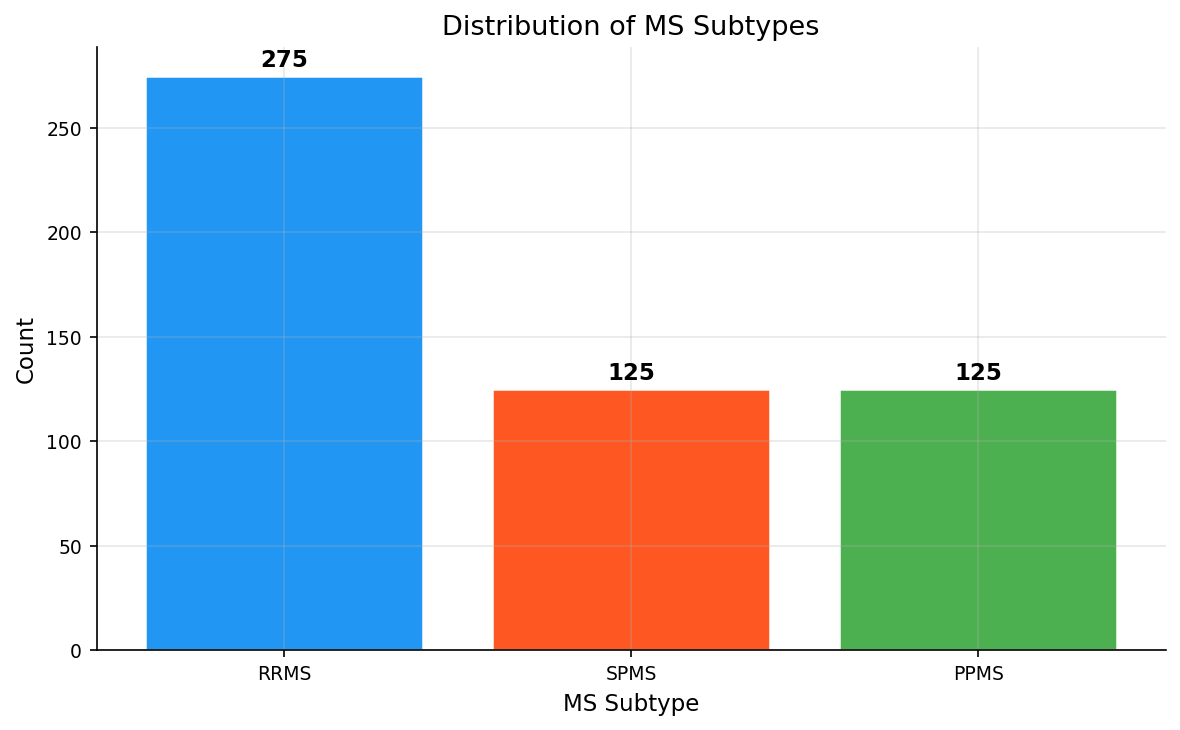

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
order = ['RRMS', 'SPMS', 'PPMS']
colors = [CLASS_PALETTE[s] for s in order]
counts = df['subtype'].value_counts().reindex(order)
bars = ax.bar(order, counts, color=colors, edgecolor='white', linewidth=1.2)
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(c), ha='center', va='bottom', fontweight='bold')
ax.set_xlabel('MS Subtype')
ax.set_ylabel('Count')
ax.set_title('Distribution of MS Subtypes')
plt.tight_layout()
plt.show()

#### Histograms of Numeric Features
Histograms reveal the distributional shape (skewness, modality) of each feature, informing preprocessing decisions.

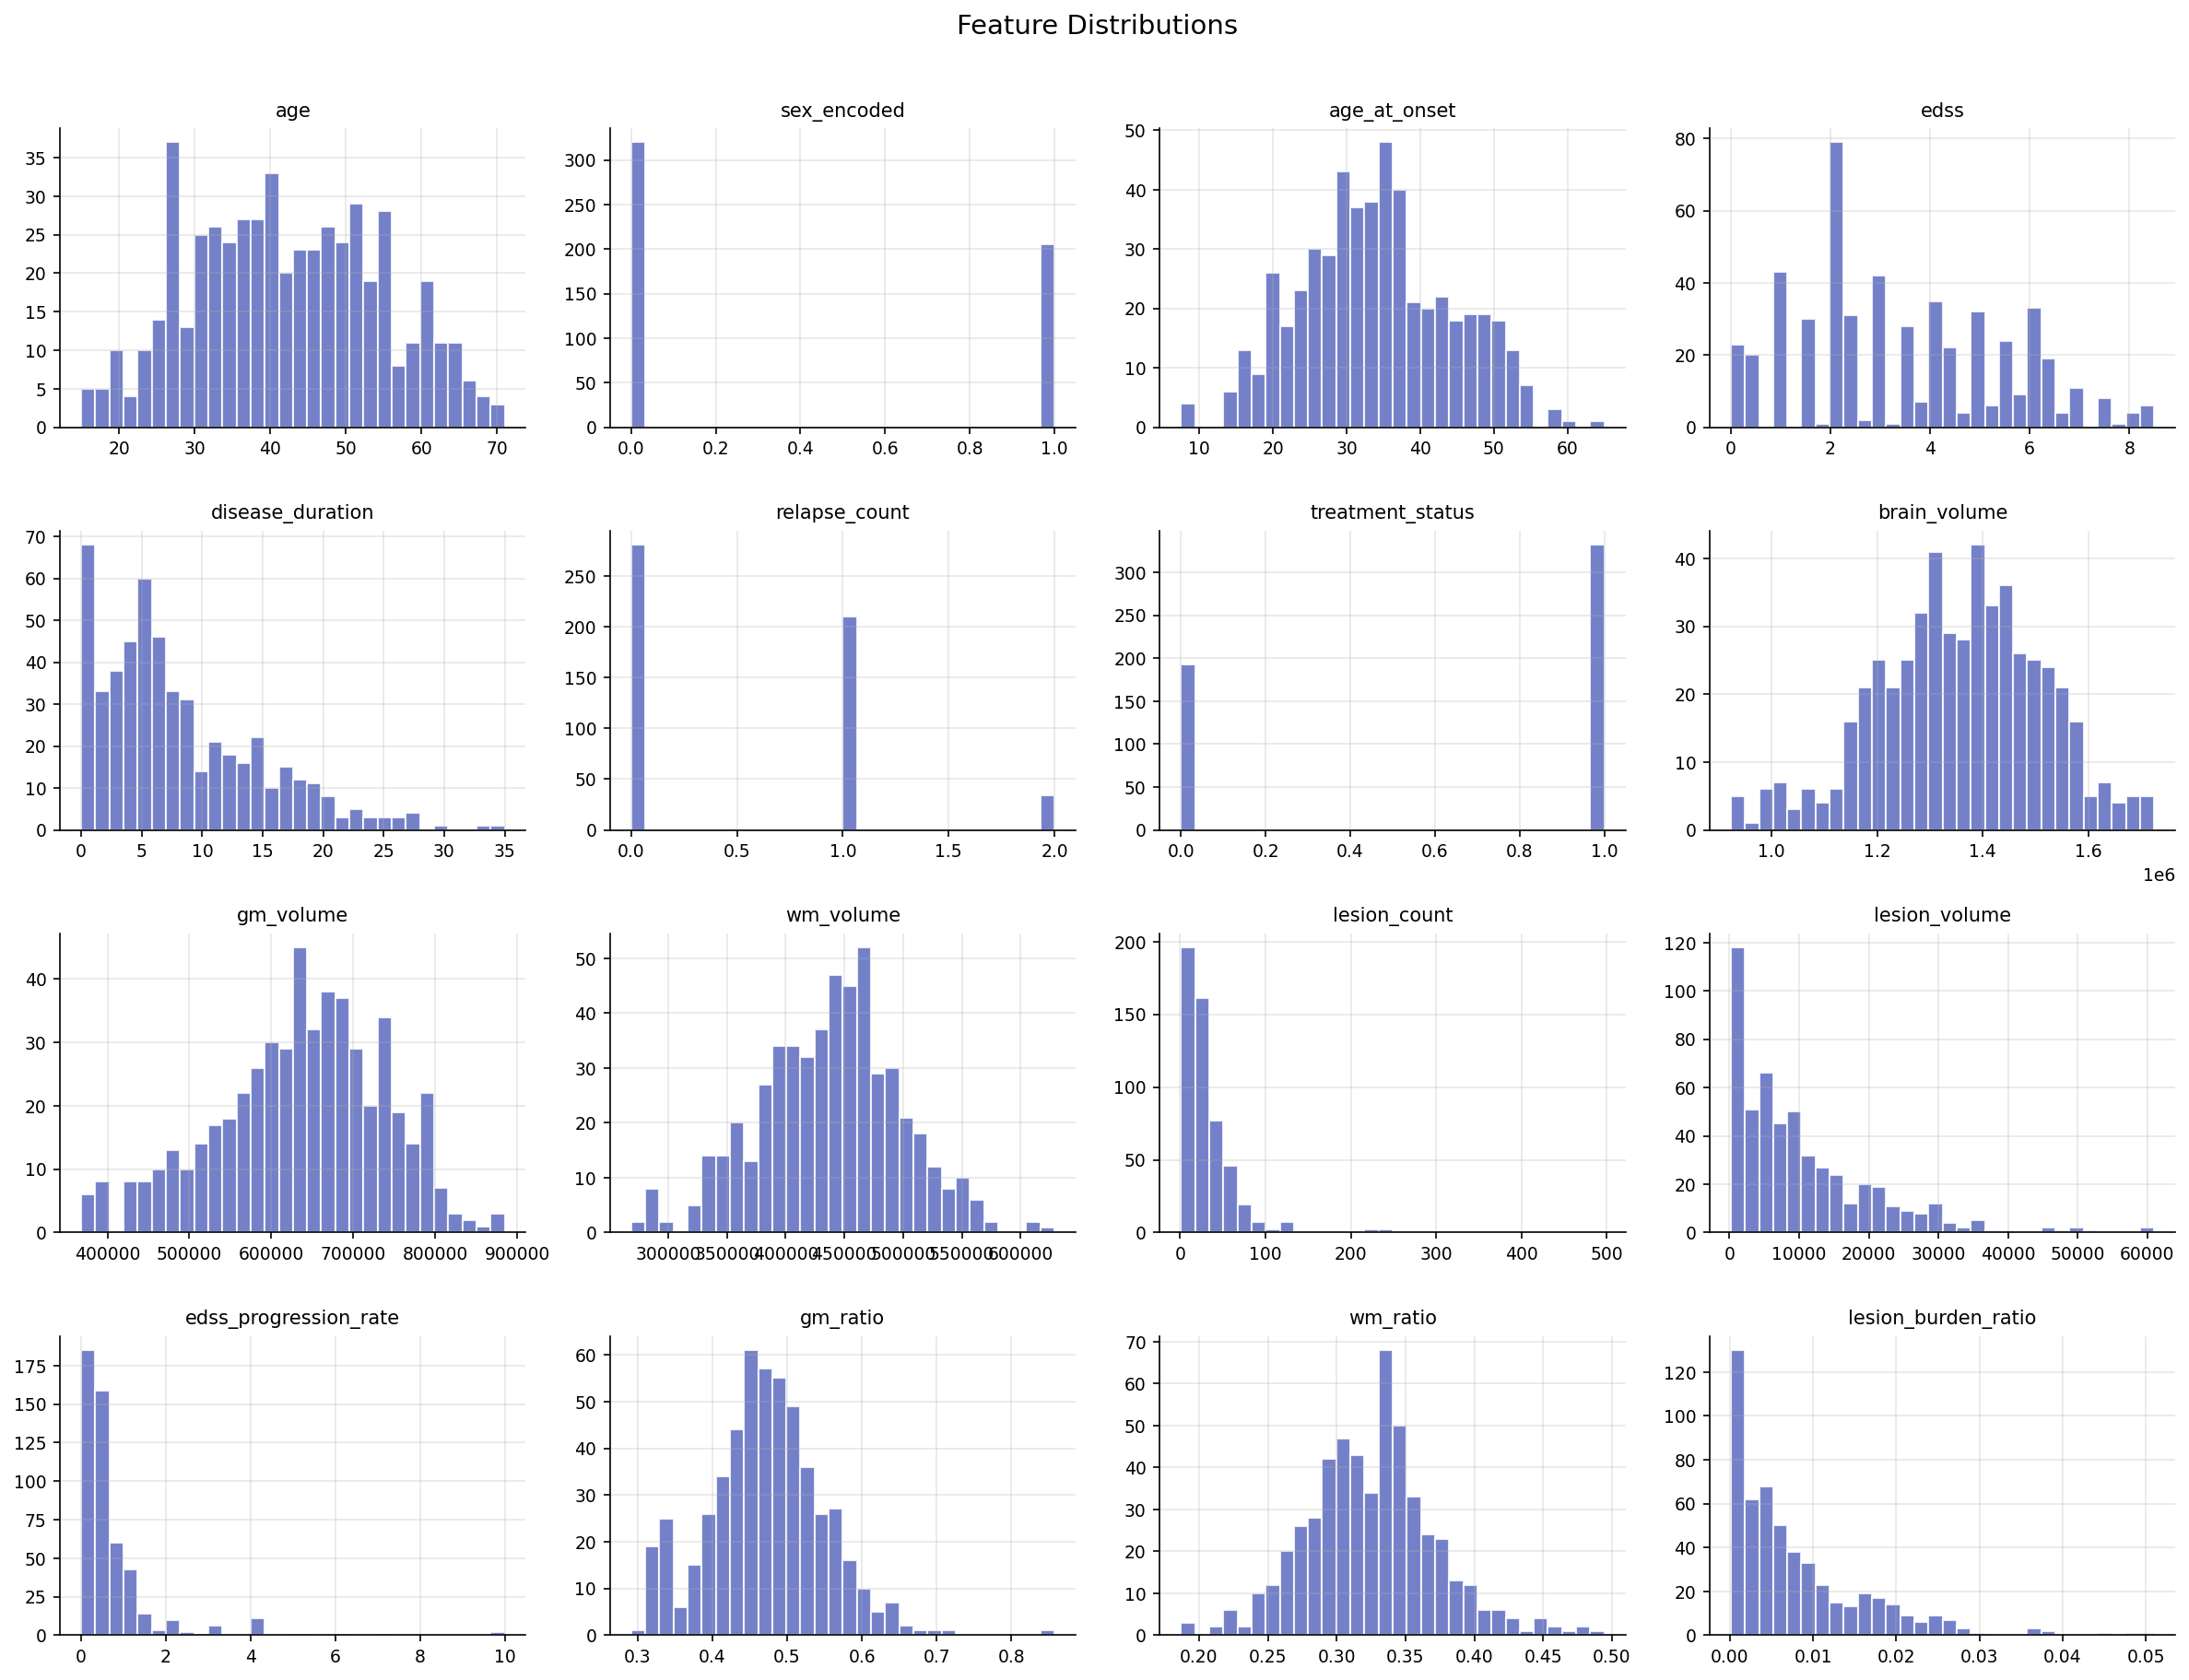

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
n = len(numeric_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    df[col].hist(ax=axes[i], bins=30, color='#5C6BC0', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

#### Boxplots Grouped by Subtype
Boxplots stratified by subtype highlight differences in feature medians, spreads, and outliers across classes — guiding clinical interpretation.

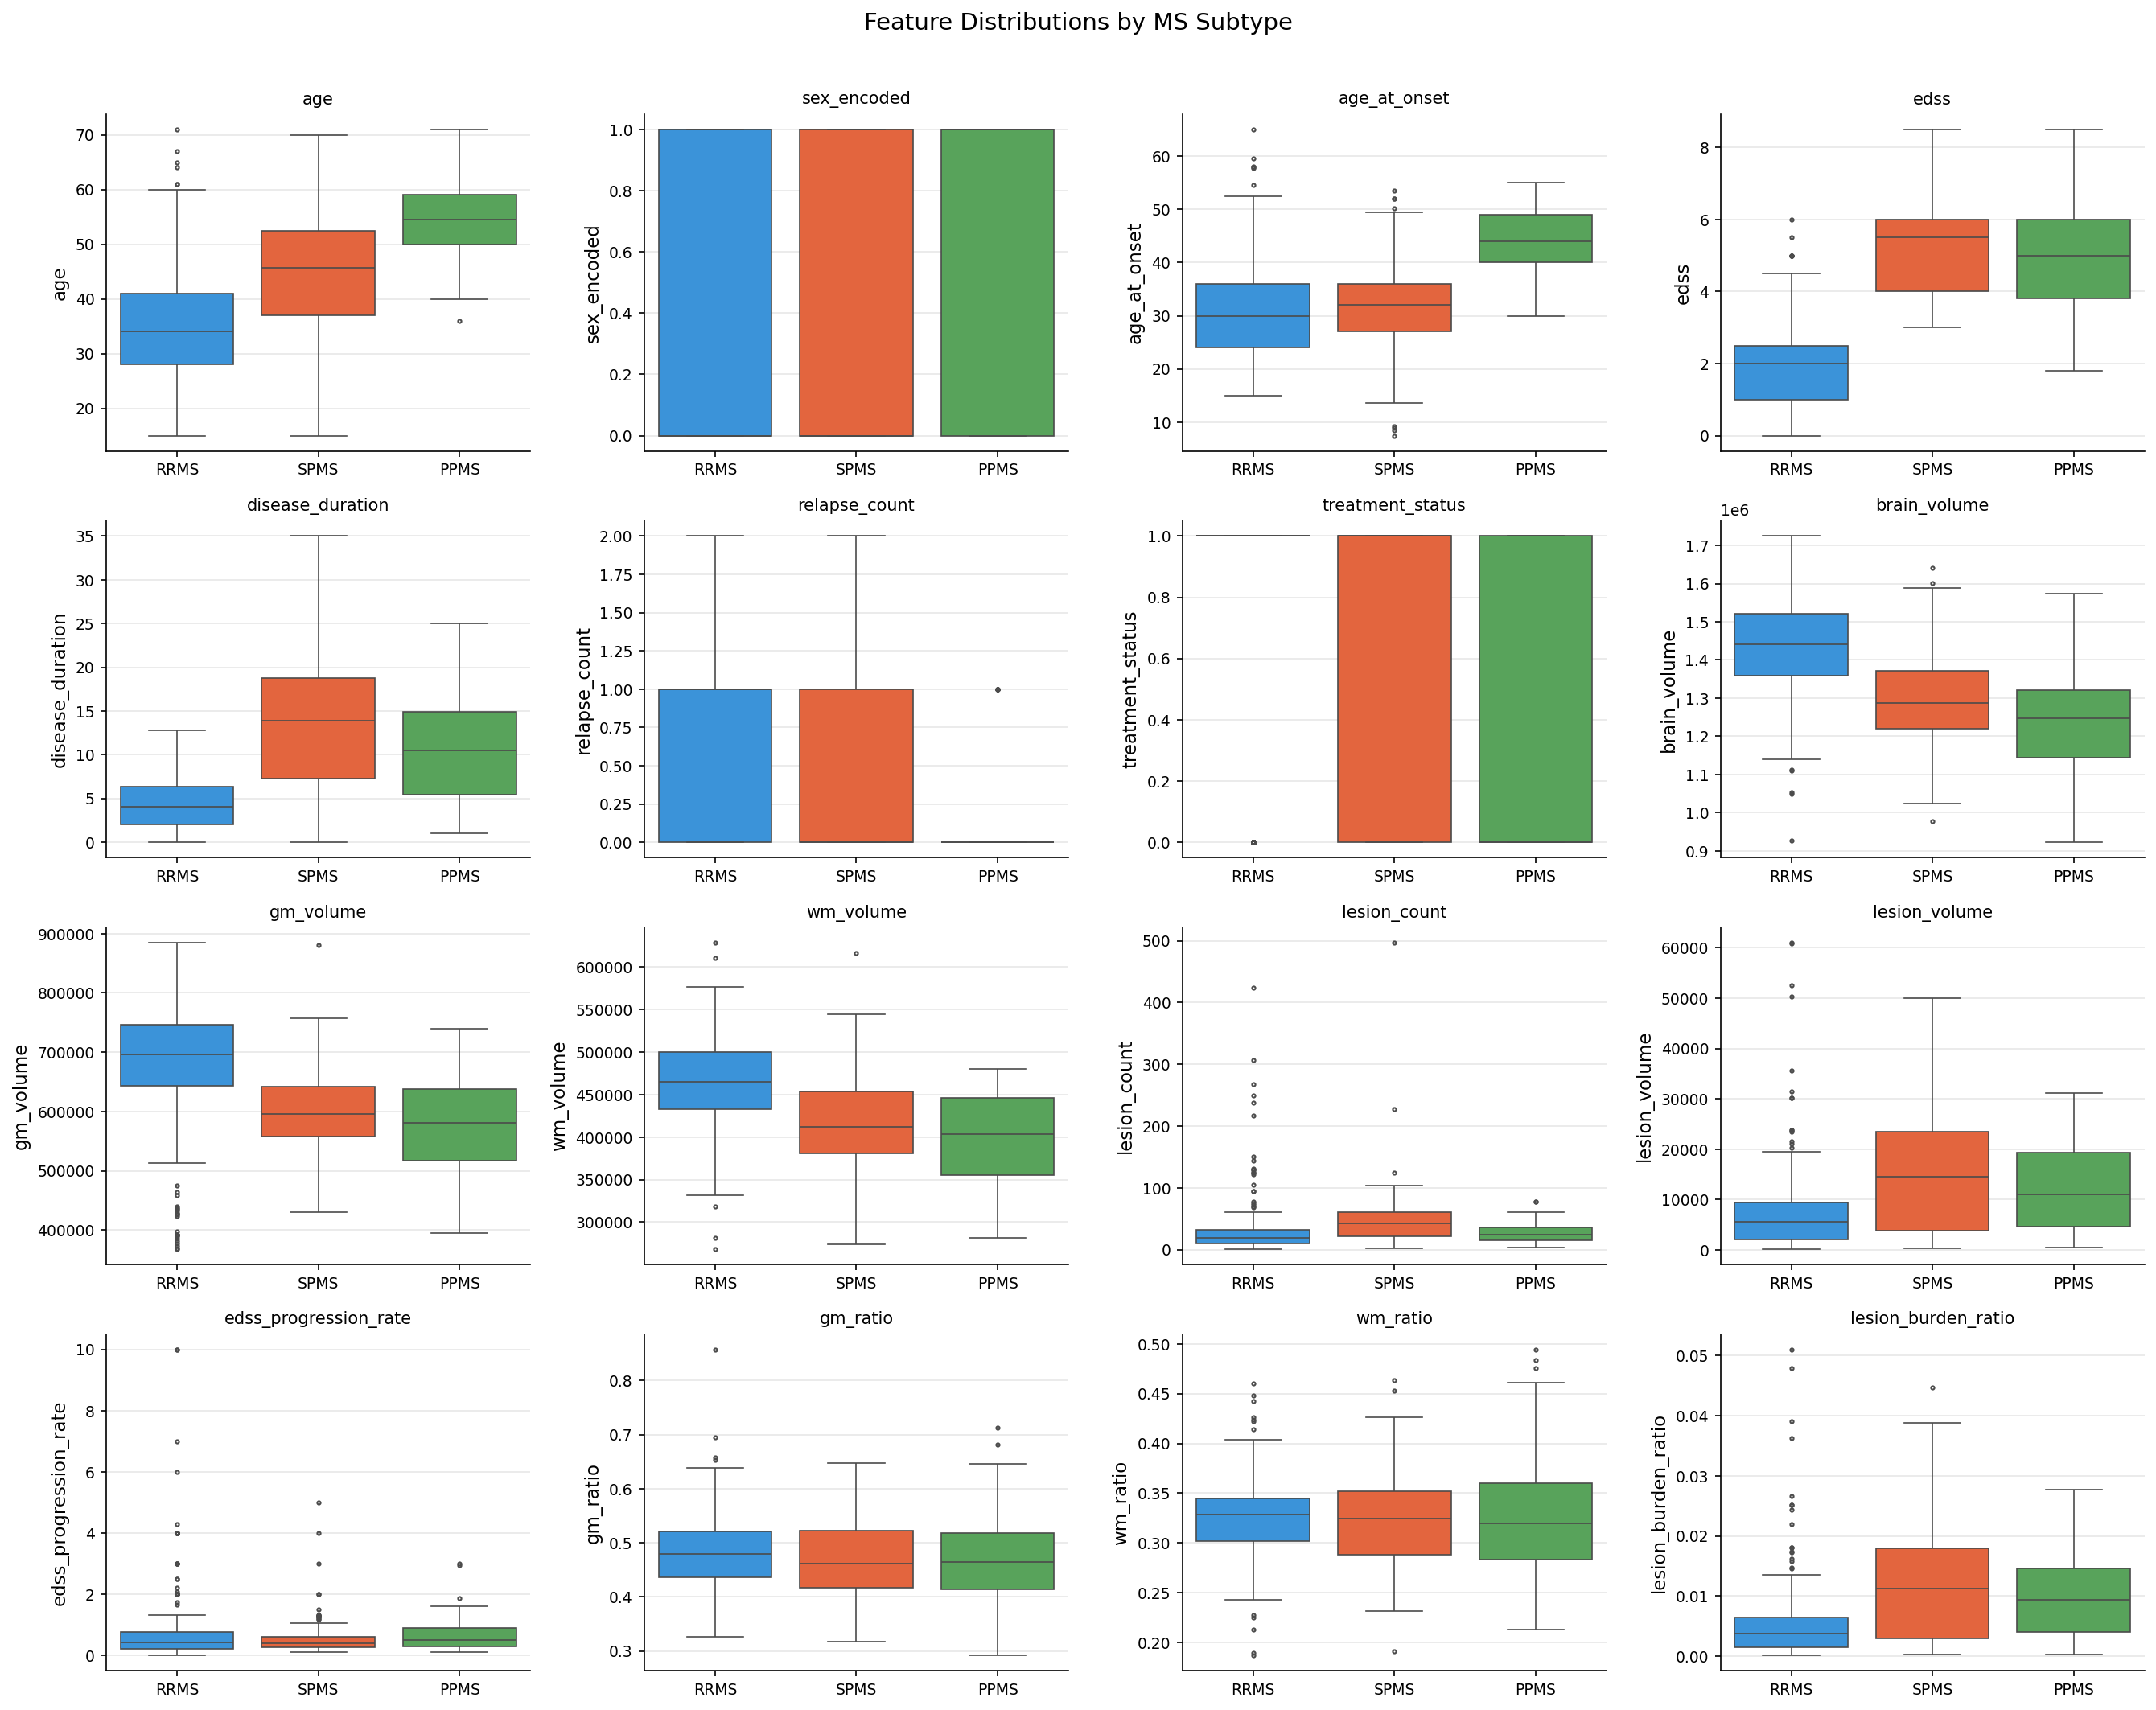

In [9]:
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='subtype', y=col, order=order,
                palette=CLASS_PALETTE, ax=axes[i], fliersize=2, linewidth=0.8)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Feature Distributions by MS Subtype', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

#### Correlation Heatmap
The heatmap exposes linear relationships among features. High correlations (|r| > 0.8) signal potential multicollinearity, which can inflate coefficient variance in logistic regression.

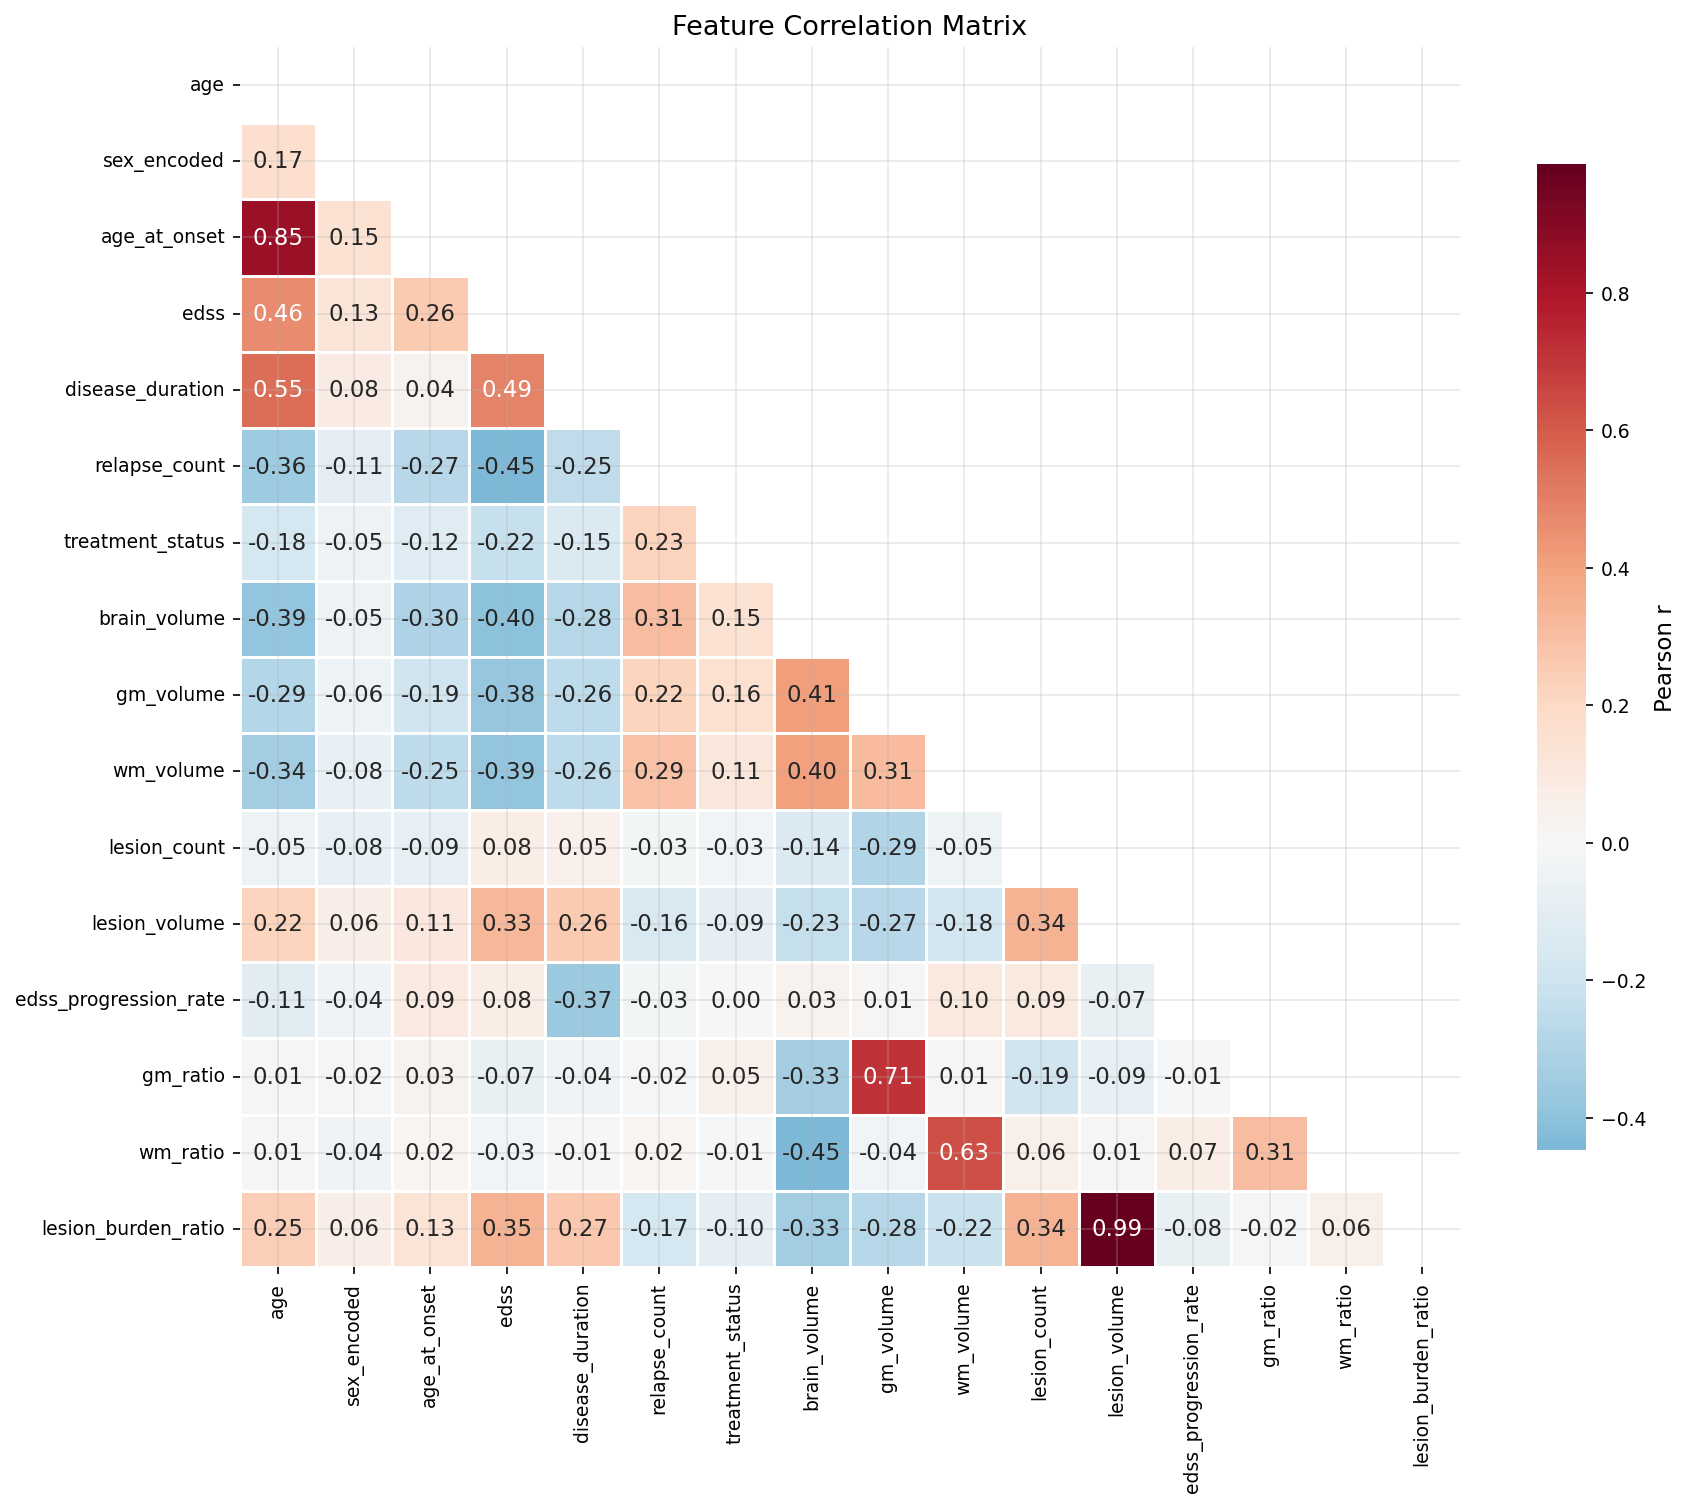

In [10]:
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

### 2.2 Clinical Interpretation of Key Observations

- **EDSS (Expanded Disability Status Scale):** Higher EDSS scores are expected in progressive subtypes (SPMS, PPMS) compared to RRMS.
- **Disease Duration & Age at Onset:** SPMS patients typically have longer disease durations, reflecting the natural transition from RRMS.
- **Relapse Count:** RRMS is characterized by relapses, while PPMS typically shows no relapses — a key discriminative feature.
- **Brain/GM/WM Volumes:** Progressive subtypes often exhibit greater atrophy (lower volumes).
- **Lesion Metrics:** Higher lesion counts and volumes are associated with more advanced disease.
- **Class Imbalance:** RRMS is the majority class, which can bias model predictions. We address this with `class_weight='balanced'`.

---
## 3. Data Preprocessing

### Data Leakage Prevention

**Data leakage** occurs when information from the test set influences model training, leading to overly optimistic performance estimates that do not generalize. To prevent this:

1. **Split first, preprocess second:** We perform the train-test split before any imputation or scaling.
2. **Fit on training data only:** Imputers and scalers learn parameters (mean, std) exclusively from the training set.
3. **Transform both sets:** The same learned parameters are applied to both training and test data.

### Why Scaling is Required for Logistic Regression

Logistic Regression uses gradient-based optimization (L-BFGS). Features on vastly different scales (e.g., `brain_volume` ~1.5M vs. `edss` ~0–9) cause:

- **Elongated loss contours** → slow, oscillating convergence
- **Disproportionate regularization** — L2 penalty treats all coefficients equally, so unscaled features receive unequal effective regularization

**StandardScaler** transforms each feature $x$ to:

$$z = \frac{x - \mu}{\sigma}$$

where $\mu$ and $\sigma$ are the training-set mean and standard deviation, respectively.

In [11]:
# Separate features and target
feature_cols = [c for c in df.columns if c != 'subtype']
X = df[feature_cols].copy()
y = df['subtype'].copy()

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_
print(f"Classes: {list(class_names)}")
print(f"Encoded: {dict(zip(class_names, le.transform(class_names)))}")

Classes: ['PPMS', 'RRMS', 'SPMS']
Encoded: {'PPMS': np.int64(0), 'RRMS': np.int64(1), 'SPMS': np.int64(2)}


In [12]:
# Stratified train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

# Verify stratification
for label, name in enumerate(class_names):
    tr_pct = (y_train == label).sum() / len(y_train) * 100
    te_pct = (y_test == label).sum() / len(y_test) * 100
    print(f"  {name}: Train {tr_pct:.1f}% | Test {te_pct:.1f}%")

Training set: 420 samples
Test set:     105 samples
  PPMS: Train 23.8% | Test 23.8%
  RRMS: Train 52.4% | Test 52.4%
  SPMS: Train 23.8% | Test 23.8%


In [13]:
# Imputation — fit ONLY on training data
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train), columns=feature_cols, index=X_train.index
)
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test), columns=feature_cols, index=X_test.index
)

print(f"Missing after imputation — Train: {X_train_imputed.isnull().sum().sum()}, "
      f"Test: {X_test_imputed.isnull().sum().sum()}")

Missing after imputation — Train: 0, Test: 0


In [14]:
# Standardization — fit ONLY on training data
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imputed), columns=feature_cols, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imputed), columns=feature_cols, index=X_test.index
)

print("Scaled training set statistics (should be ~0 mean, ~1 std):")
print(X_train_scaled.describe().loc[['mean', 'std']].round(3))

Scaled training set statistics (should be ~0 mean, ~1 std):
        age  sex_encoded  age_at_onset   edss  disease_duration  \
mean  0.000       -0.000         0.000  0.000             0.000   
std   1.001        1.001         1.001  1.001             1.001   

      relapse_count  treatment_status  brain_volume  gm_volume  wm_volume  \
mean          0.000             0.000        -0.000     -0.000      0.000   
std           1.001             1.001         1.001      1.001      1.001   

      lesion_count  lesion_volume  edss_progression_rate  gm_ratio  wm_ratio  \
mean         0.000          0.000                 -0.000    -0.000    -0.000   
std          1.001          1.001                  1.001     1.001     1.001   

      lesion_burden_ratio  
mean               -0.000  
std                 1.001  


---
## 4. Model Building — Multinomial Logistic Regression

### Multinomial Softmax Formulation

For $K$ classes, the model estimates:

$$P(Y = k \mid \mathbf{x}) = \frac{\exp(\mathbf{w}_k^T \mathbf{x} + b_k)}{\sum_{j=1}^{K} \exp(\mathbf{w}_j^T \mathbf{x} + b_j)}$$

where $\mathbf{w}_k$ is the coefficient vector for class $k$.

### Regularization (L2)

L2 regularization adds a penalty $\lambda \sum_k \|\mathbf{w}_k\|_2^2$ to the loss function, which:
- Prevents overfitting by shrinking coefficients toward zero
- Improves numerical stability
- Encourages distributed feature contributions rather than reliance on a single feature

### Configuration Choices

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `solver` | `lbfgs` | Efficient quasi-Newton method for multinomial problems |
| `max_iter` | `1000` | Sufficient iterations for convergence |
| `class_weight` | `balanced` | Adjusts for class imbalance by up-weighting minority classes |
| `C` | `1.0` | Default inverse regularization strength |

In [15]:
# Build the Multinomial Logistic Regression model
model = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    C=1.0,
    random_state=RANDOM_STATE
)

print("Model Configuration:")
print(model)

Model Configuration:
LogisticRegression(class_weight='balanced', max_iter=1000, penalty='l2',
                   random_state=42)


---
## 5. Stratified 5-Fold Cross-Validation

Cross-validation provides a robust estimate of model generalization by:
1. Training and evaluating on **different subsets** of the training data
2. Reporting **mean ± std** of metrics to assess stability

### Why Macro F1-Score Matters in Multi-Class Settings

- **Macro F1** computes F1 per class and averages equally, giving **equal importance to minority classes**
- This is critical when all subtypes are clinically important, regardless of prevalence
- A high accuracy with low Macro F1 indicates the model fails on rare classes

### Bias–Variance Interpretation

- **Low variance across folds** → stable model, unlikely to overfit
- **High variance** → sensitivity to data splits, suggesting insufficient data or model complexity

In [16]:
# Stratified 5-Fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted'
}

cv_results = cross_validate(
    model, X_train_scaled, y_train,
    cv=cv, scoring=scoring, return_train_score=False
)

print("Cross-Validation Results (5-Fold):")
print(f"  Accuracy:       {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"  Macro F1:       {cv_results['test_f1_macro'].mean():.4f} ± {cv_results['test_f1_macro'].std():.4f}")
print(f"  Weighted F1:    {cv_results['test_f1_weighted'].mean():.4f} ± {cv_results['test_f1_weighted'].std():.4f}")

Cross-Validation Results (5-Fold):
  Accuracy:       0.8762 ± 0.0307
  Macro F1:       0.8484 ± 0.0430
  Weighted F1:    0.8766 ± 0.0316


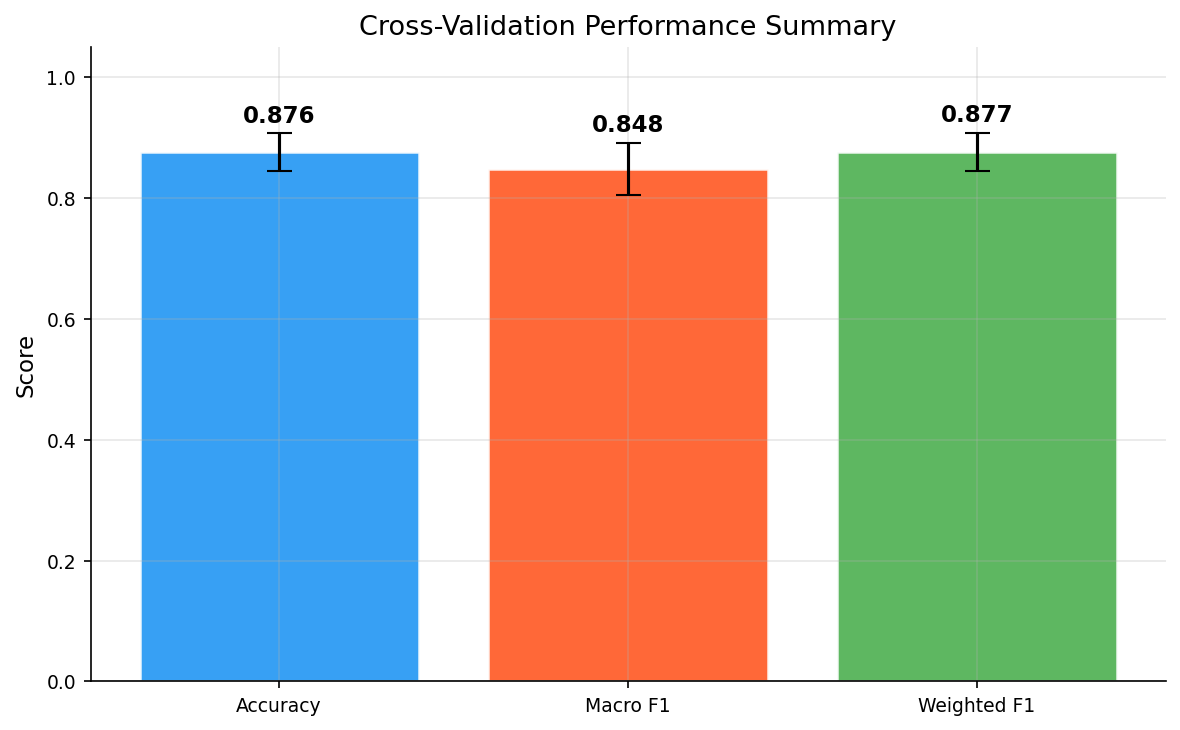

In [17]:
# Bar chart of CV metrics
metrics_names = ['Accuracy', 'Macro F1', 'Weighted F1']
means = [cv_results[f'test_{m}'].mean() for m in ['accuracy', 'f1_macro', 'f1_weighted']]
stds = [cv_results[f'test_{m}'].std() for m in ['accuracy', 'f1_macro', 'f1_weighted']]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(metrics_names, means, yerr=stds, capsize=6,
              color=['#2196F3', '#FF5722', '#4CAF50'], edgecolor='white', linewidth=1.2, alpha=0.9)
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.01,
            f'{m:.3f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Cross-Validation Performance Summary')
plt.tight_layout()
plt.show()

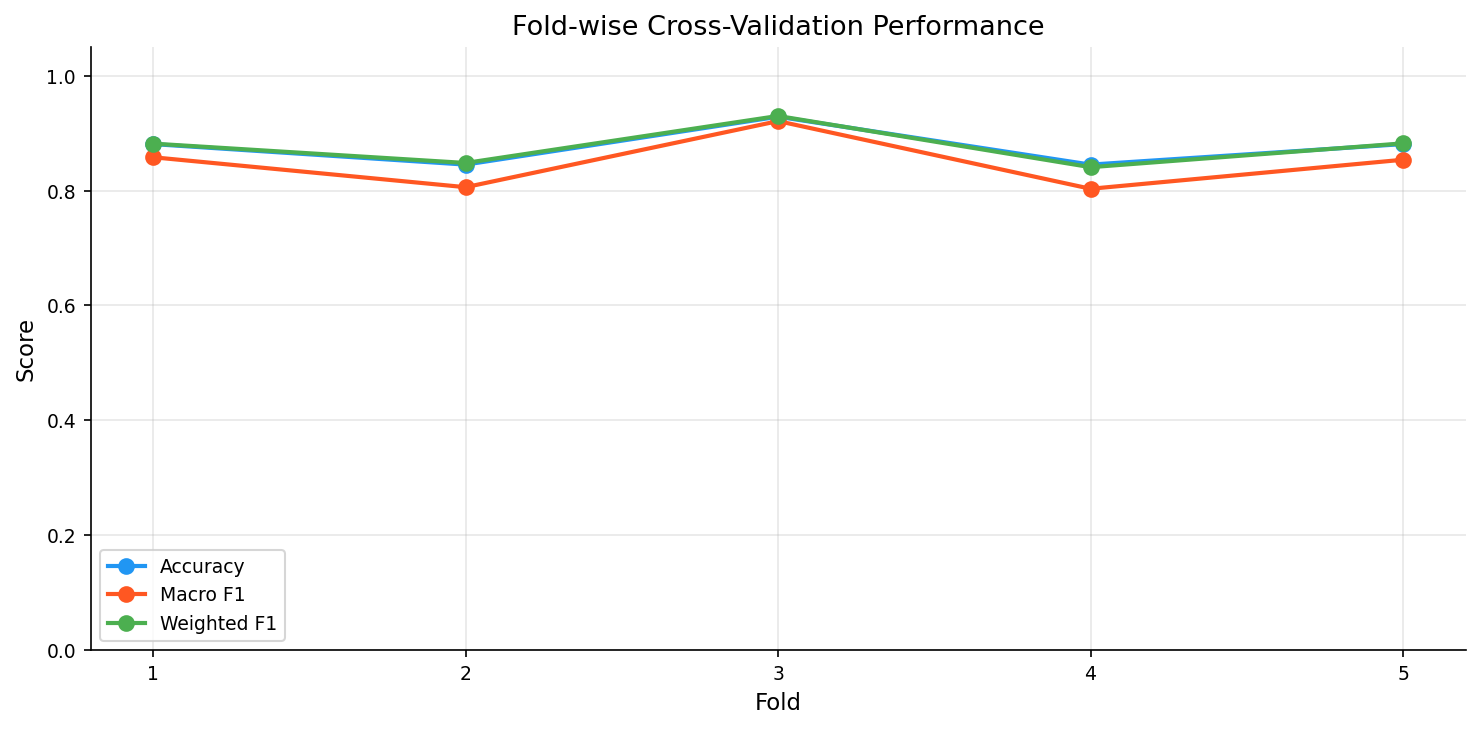

In [18]:
# Fold-wise performance
fig, ax = plt.subplots(figsize=(10, 5))
folds = range(1, 6)
for key, label, color in [('test_accuracy', 'Accuracy', '#2196F3'),
                           ('test_f1_macro', 'Macro F1', '#FF5722'),
                           ('test_f1_weighted', 'Weighted F1', '#4CAF50')]:
    ax.plot(folds, cv_results[key], 'o-', label=label, color=color, linewidth=2, markersize=7)
ax.set_xlabel('Fold')
ax.set_ylabel('Score')
ax.set_title('Fold-wise Cross-Validation Performance')
ax.set_xticks(list(folds))
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

---
## 6. Final Model Training

### Why Retrain on the Full Training Set?

During cross-validation, the model was trained on only 80% of the training data in each fold. Now that we have validated performance, we retrain on the **entire training set** to:

1. **Maximize information** available for learning decision boundaries
2. **Produce the definitive model** for test-set evaluation
3. **Obtain stable coefficients** for interpretation

In [19]:
# Train on full training set
model.fit(X_train_scaled, y_train)

print("Model trained on full training set.")
print(f"  Training samples: {X_train_scaled.shape[0]}")
print(f"  Features: {X_train_scaled.shape[1]}")
print(f"  Classes: {list(class_names)}")
print(f"  Converged: {model.n_iter_[0]} iterations")

Model trained on full training set.
  Training samples: 420
  Features: 16
  Classes: ['PPMS', 'RRMS', 'SPMS']
  Converged: 30 iterations


---
## 7. Evaluation on Test Set

We evaluate the trained model on the held-out test set using multiple metrics to capture different aspects of performance.

In [20]:
# Predictions
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)

# Overall metrics
acc = accuracy_score(y_test, y_pred)
f1_mac = f1_score(y_test, y_pred, average='macro')
f1_wt = f1_score(y_test, y_pred, average='weighted')

print("Test Set Performance:")
print(f"  Accuracy:       {acc:.4f}")
print(f"  Macro F1:       {f1_mac:.4f}")
print(f"  Weighted F1:    {f1_wt:.4f}")

# Per-class metrics
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

Test Set Performance:
  Accuracy:       0.8571
  Macro F1:       0.8270
  Weighted F1:    0.8581

Detailed Classification Report:
              precision    recall  f1-score   support

        PPMS     0.8000    0.8000    0.8000        25
        RRMS     0.9444    0.9273    0.9358        55
        SPMS     0.7308    0.7600    0.7451        25

    accuracy                         0.8571       105
   macro avg     0.8251    0.8291    0.8270       105
weighted avg     0.8592    0.8571    0.8581       105



In [21]:
# OvR ROC-AUC
y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
try:
    roc_auc_ovr = roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='macro')
    print(f"One-vs-Rest ROC-AUC (macro): {roc_auc_ovr:.4f}")
except ValueError as e:
    print(f"ROC-AUC could not be computed: {e}")
    roc_auc_ovr = None

One-vs-Rest ROC-AUC (macro): 0.9674


### 7.1 Confusion Matrix

The confusion matrix reveals where the model confuses subtypes. Off-diagonal entries represent misclassifications.

**Clinical Significance:**
- **False Positives (FP):** A patient misclassified as having a more severe subtype (e.g., RRMS → SPMS) may receive unnecessarily aggressive treatment.
- **False Negatives (FN):** A progressive subtype misclassified as RRMS may delay escalation of therapy, risking irreversible disability.

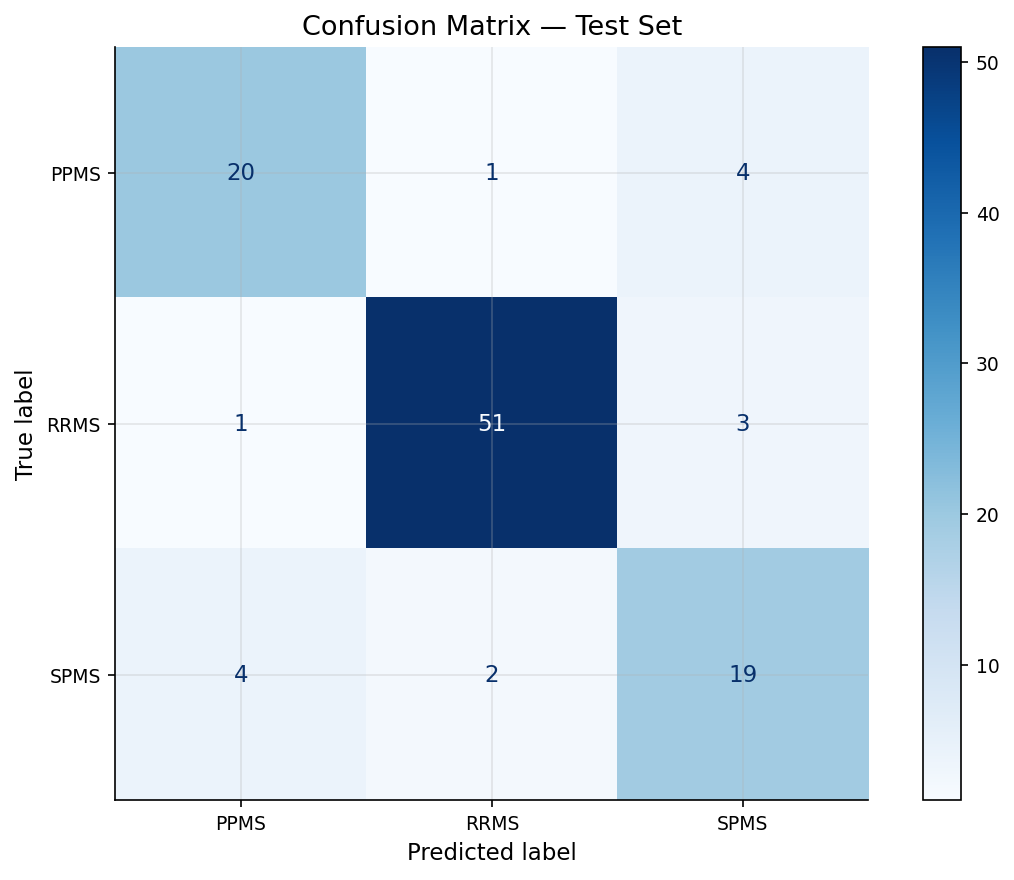

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

### 7.2 ROC Curves (One-vs-Rest)

ROC curves plot the True Positive Rate against the False Positive Rate at varying classification thresholds. The Area Under the Curve (AUC) summarizes discriminative ability; AUC = 1.0 indicates perfect separation.

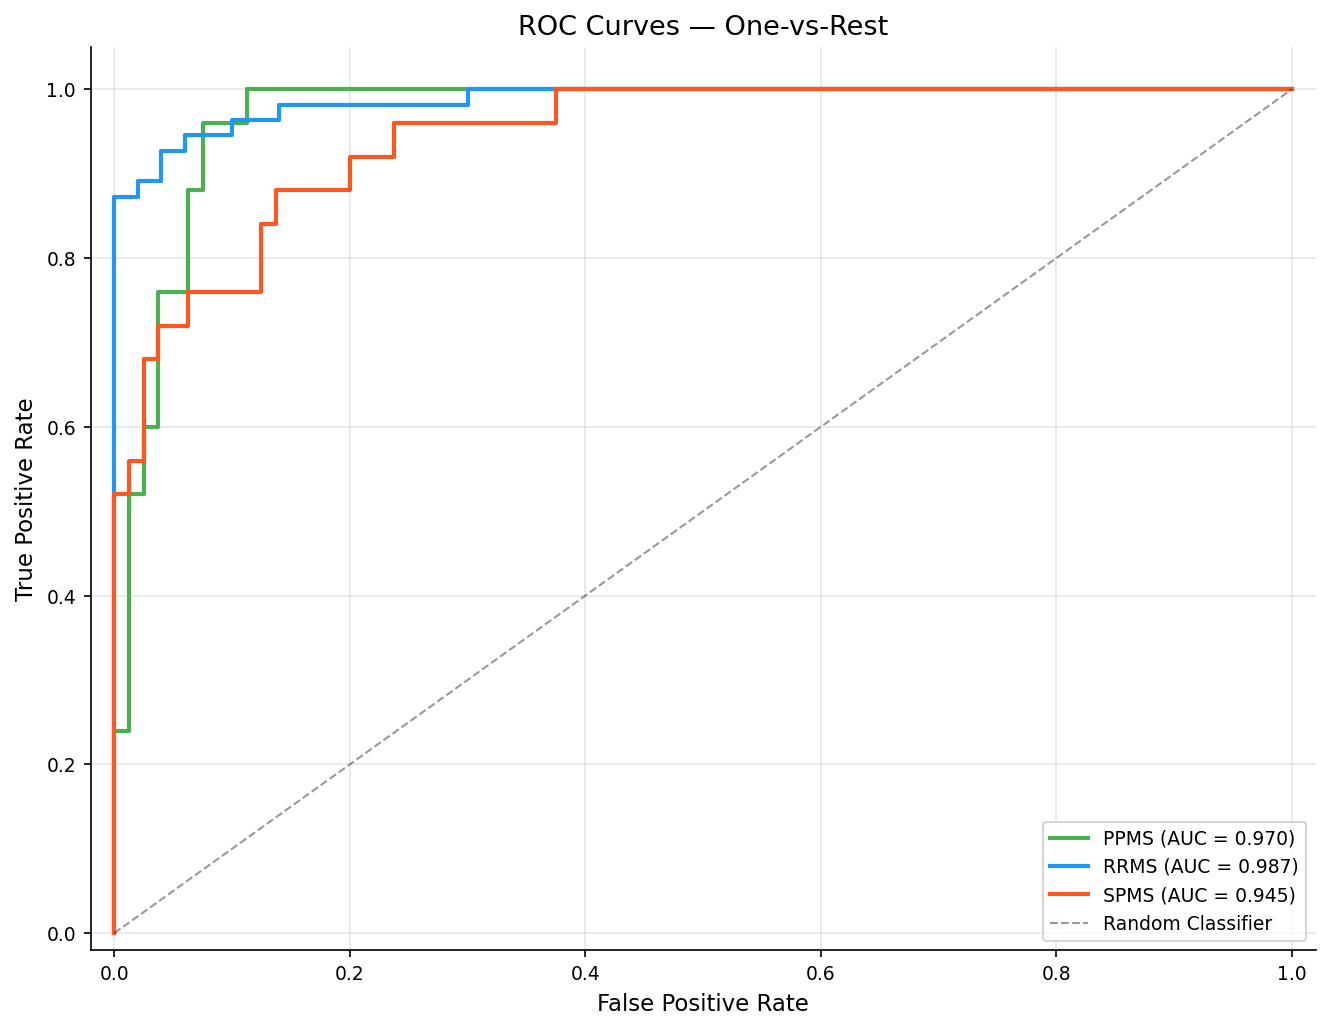

In [23]:
fig, ax = plt.subplots(figsize=(9, 7))
for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc_i = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc_i:.3f})',
            color=CLASS_PALETTE.get(name, None))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — One-vs-Rest')
ax.legend(loc='lower right')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
plt.tight_layout()
plt.show()

### 7.3 Precision-Recall Curves

Precision-Recall curves are especially informative for imbalanced classes, as they focus on the model's ability to identify positive instances without flooding predictions with false positives.

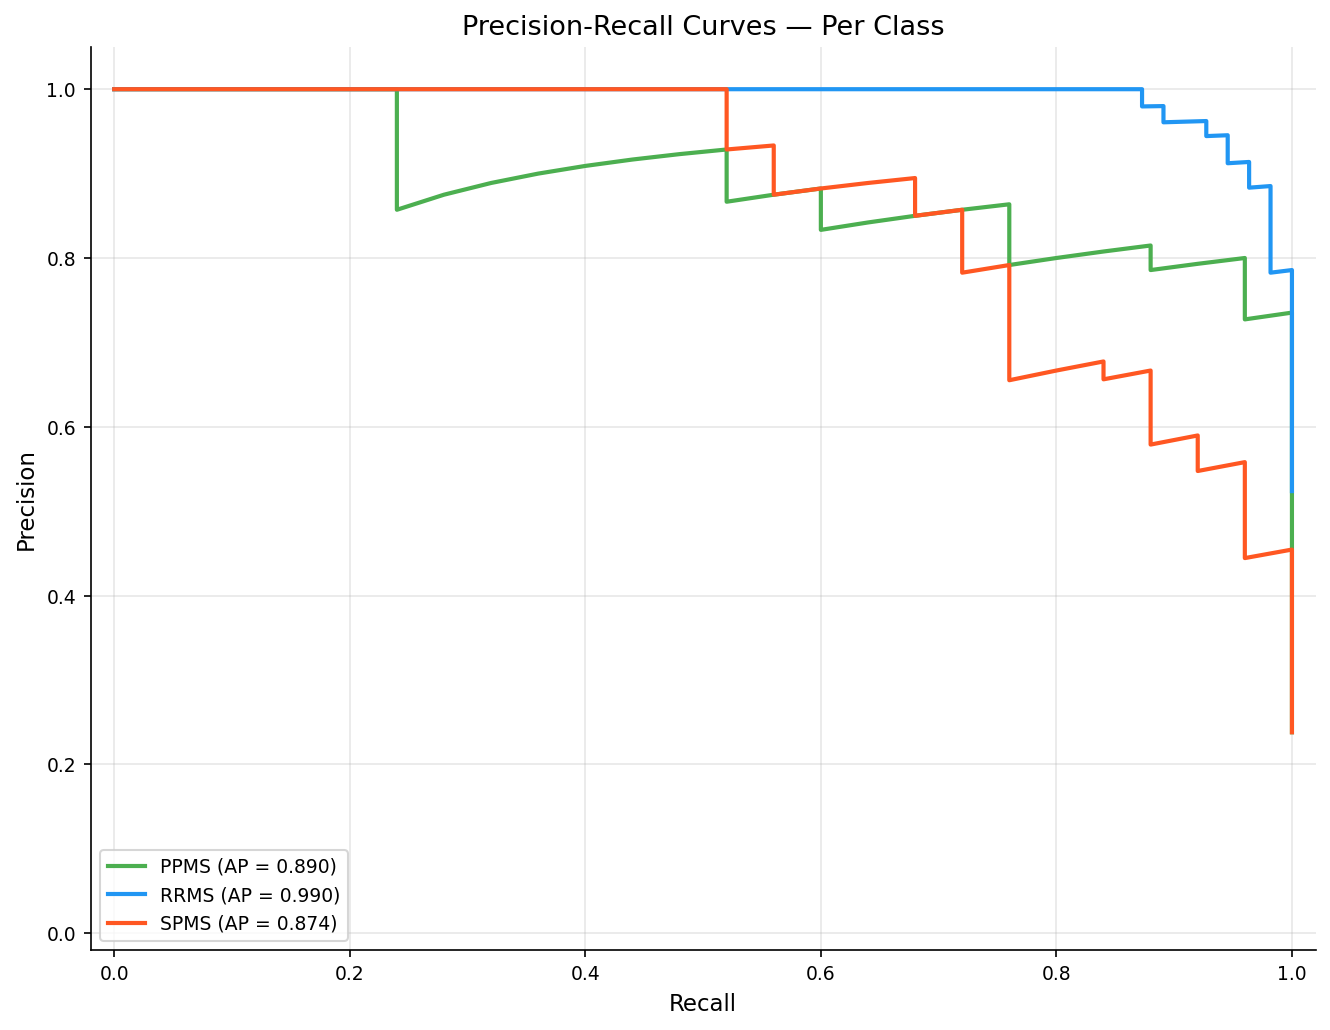

In [24]:
fig, ax = plt.subplots(figsize=(9, 7))
for i, name in enumerate(class_names):
    prec, rec, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_proba[:, i])
    ax.plot(rec, prec, linewidth=2, label=f'{name} (AP = {ap:.3f})',
            color=CLASS_PALETTE.get(name, None))
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — Per Class')
ax.legend(loc='lower left')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
plt.tight_layout()
plt.show()

### 7.4 Misclassification Analysis

Examining which samples are misclassified helps identify patterns the model struggles with — potentially highlighting atypical presentations or boundary cases between subtypes.

Misclassified: 15 / 105 (14.3%)

Most common misclassification pairs:
True Predicted  Count
PPMS      SPMS      4
SPMS      PPMS      4
RRMS      SPMS      3
SPMS      RRMS      2
PPMS      RRMS      1
RRMS      PPMS      1


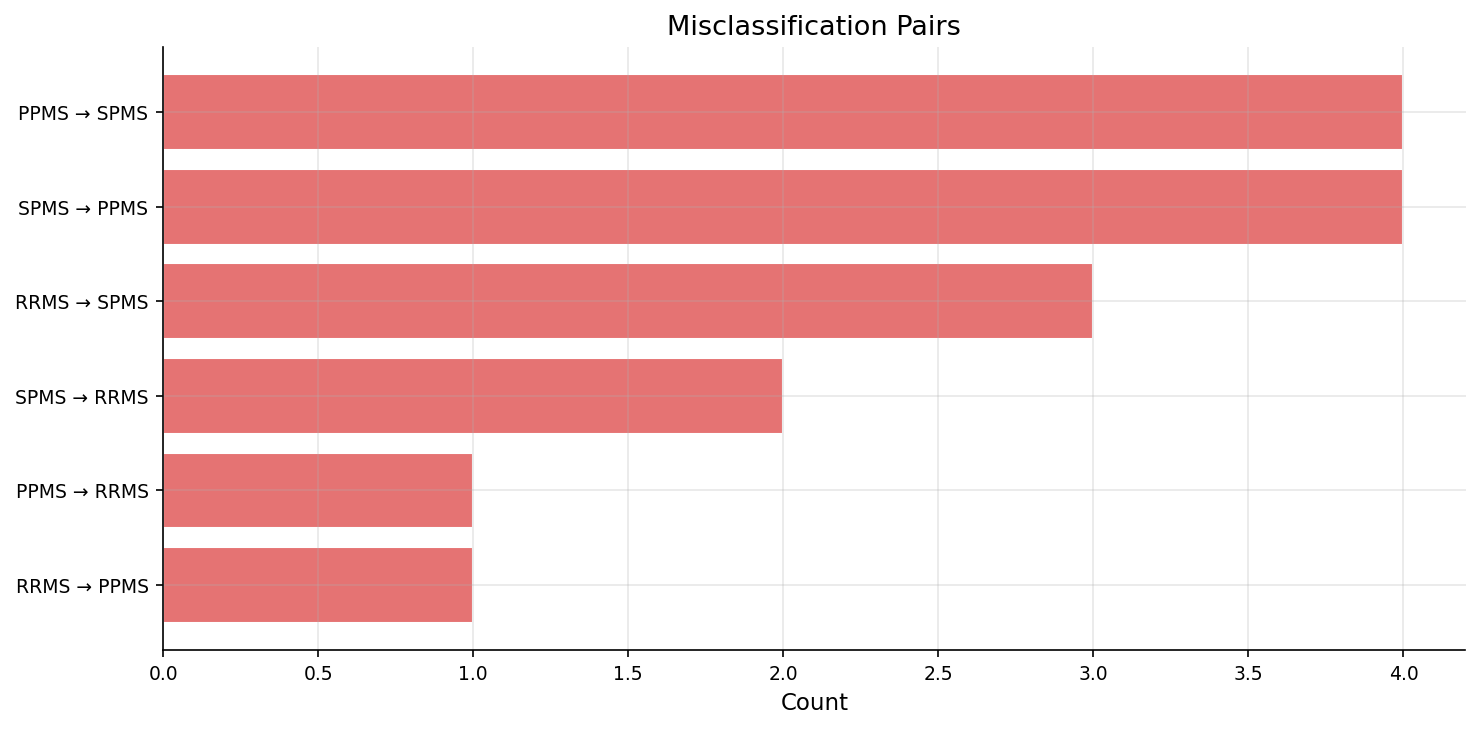

In [25]:
# Misclassification analysis
misclassified_mask = y_pred != y_test
n_mis = misclassified_mask.sum()
print(f"Misclassified: {n_mis} / {len(y_test)} ({n_mis/len(y_test)*100:.1f}%)")

# Confusion pairs
mis_pairs = pd.DataFrame({'True': class_names[y_test[misclassified_mask]],
                           'Predicted': class_names[y_pred[misclassified_mask]]})
pair_counts = mis_pairs.groupby(['True', 'Predicted']).size().reset_index(name='Count')
pair_counts = pair_counts.sort_values('Count', ascending=False)
print("\nMost common misclassification pairs:")
print(pair_counts.to_string(index=False))

# Plot
if len(pair_counts) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    labels = [f"{r['True']} → {r['Predicted']}" for _, r in pair_counts.iterrows()]
    ax.barh(labels[::-1], pair_counts['Count'].values[::-1], color='#E57373', edgecolor='white')
    ax.set_xlabel('Count')
    ax.set_title('Misclassification Pairs')
    plt.tight_layout()
    plt.show()

---
## 8. Coefficient and Feature Analysis

### Interpreting Logistic Regression Coefficients

For each class $k$, the coefficient $w_{k,j}$ for feature $j$ represents the change in **log-odds** of class $k$ (vs. the reference) per unit increase in $x_j$ (after standardization):

$$\log\frac{P(Y=k)}{P(Y=\text{ref})} = \mathbf{w}_k^T \mathbf{x} + b_k$$

- **Positive coefficient** → feature increases the probability of that subtype
- **Negative coefficient** → feature decreases the probability
- **Magnitude** → strength of the association

### Limitations

Linear models assume a linear relationship in the log-odds space. Complex nonlinear biological interactions (e.g., gene-environment, threshold effects in neurodegeneration) may not be captured.

In [26]:
# Coefficient table
coef_df = pd.DataFrame(model.coef_, columns=feature_cols, index=class_names)
print("Model Coefficients (per class):")
coef_df.round(4)

Model Coefficients (per class):


,age,sex_encoded,age_at_onset,edss,disease_duration,relapse_count,treatment_status,brain_volume,gm_volume,wm_volume,lesion_count,lesion_volume,edss_progression_rate,gm_ratio,wm_ratio,lesion_burden_ratio
PPMS,0.6964,0.2149,0.8878,1.3117,0.1240,-1.0420,-0.4975,-0.1067,-0.8406,-0.7763,-0.7983,-0.2687,-0.3382,0.4148,0.2446,-0.1363
RRMS,-0.5867,-0.1504,-0.2916,-2.7094,-0.8087,1.1509,0.4712,0.4969,0.6592,0.3285,0.3630,-0.0096,0.2818,-0.3683,-0.0473,0.2292
SPMS,-0.1096,-0.0644,-0.5962,1.3976,0.6846,-0.1089,0.0263,-0.3902,0.1813,0.4478,0.4353,0.2783,0.0564,-0.0465,-0.1972,-0.0929


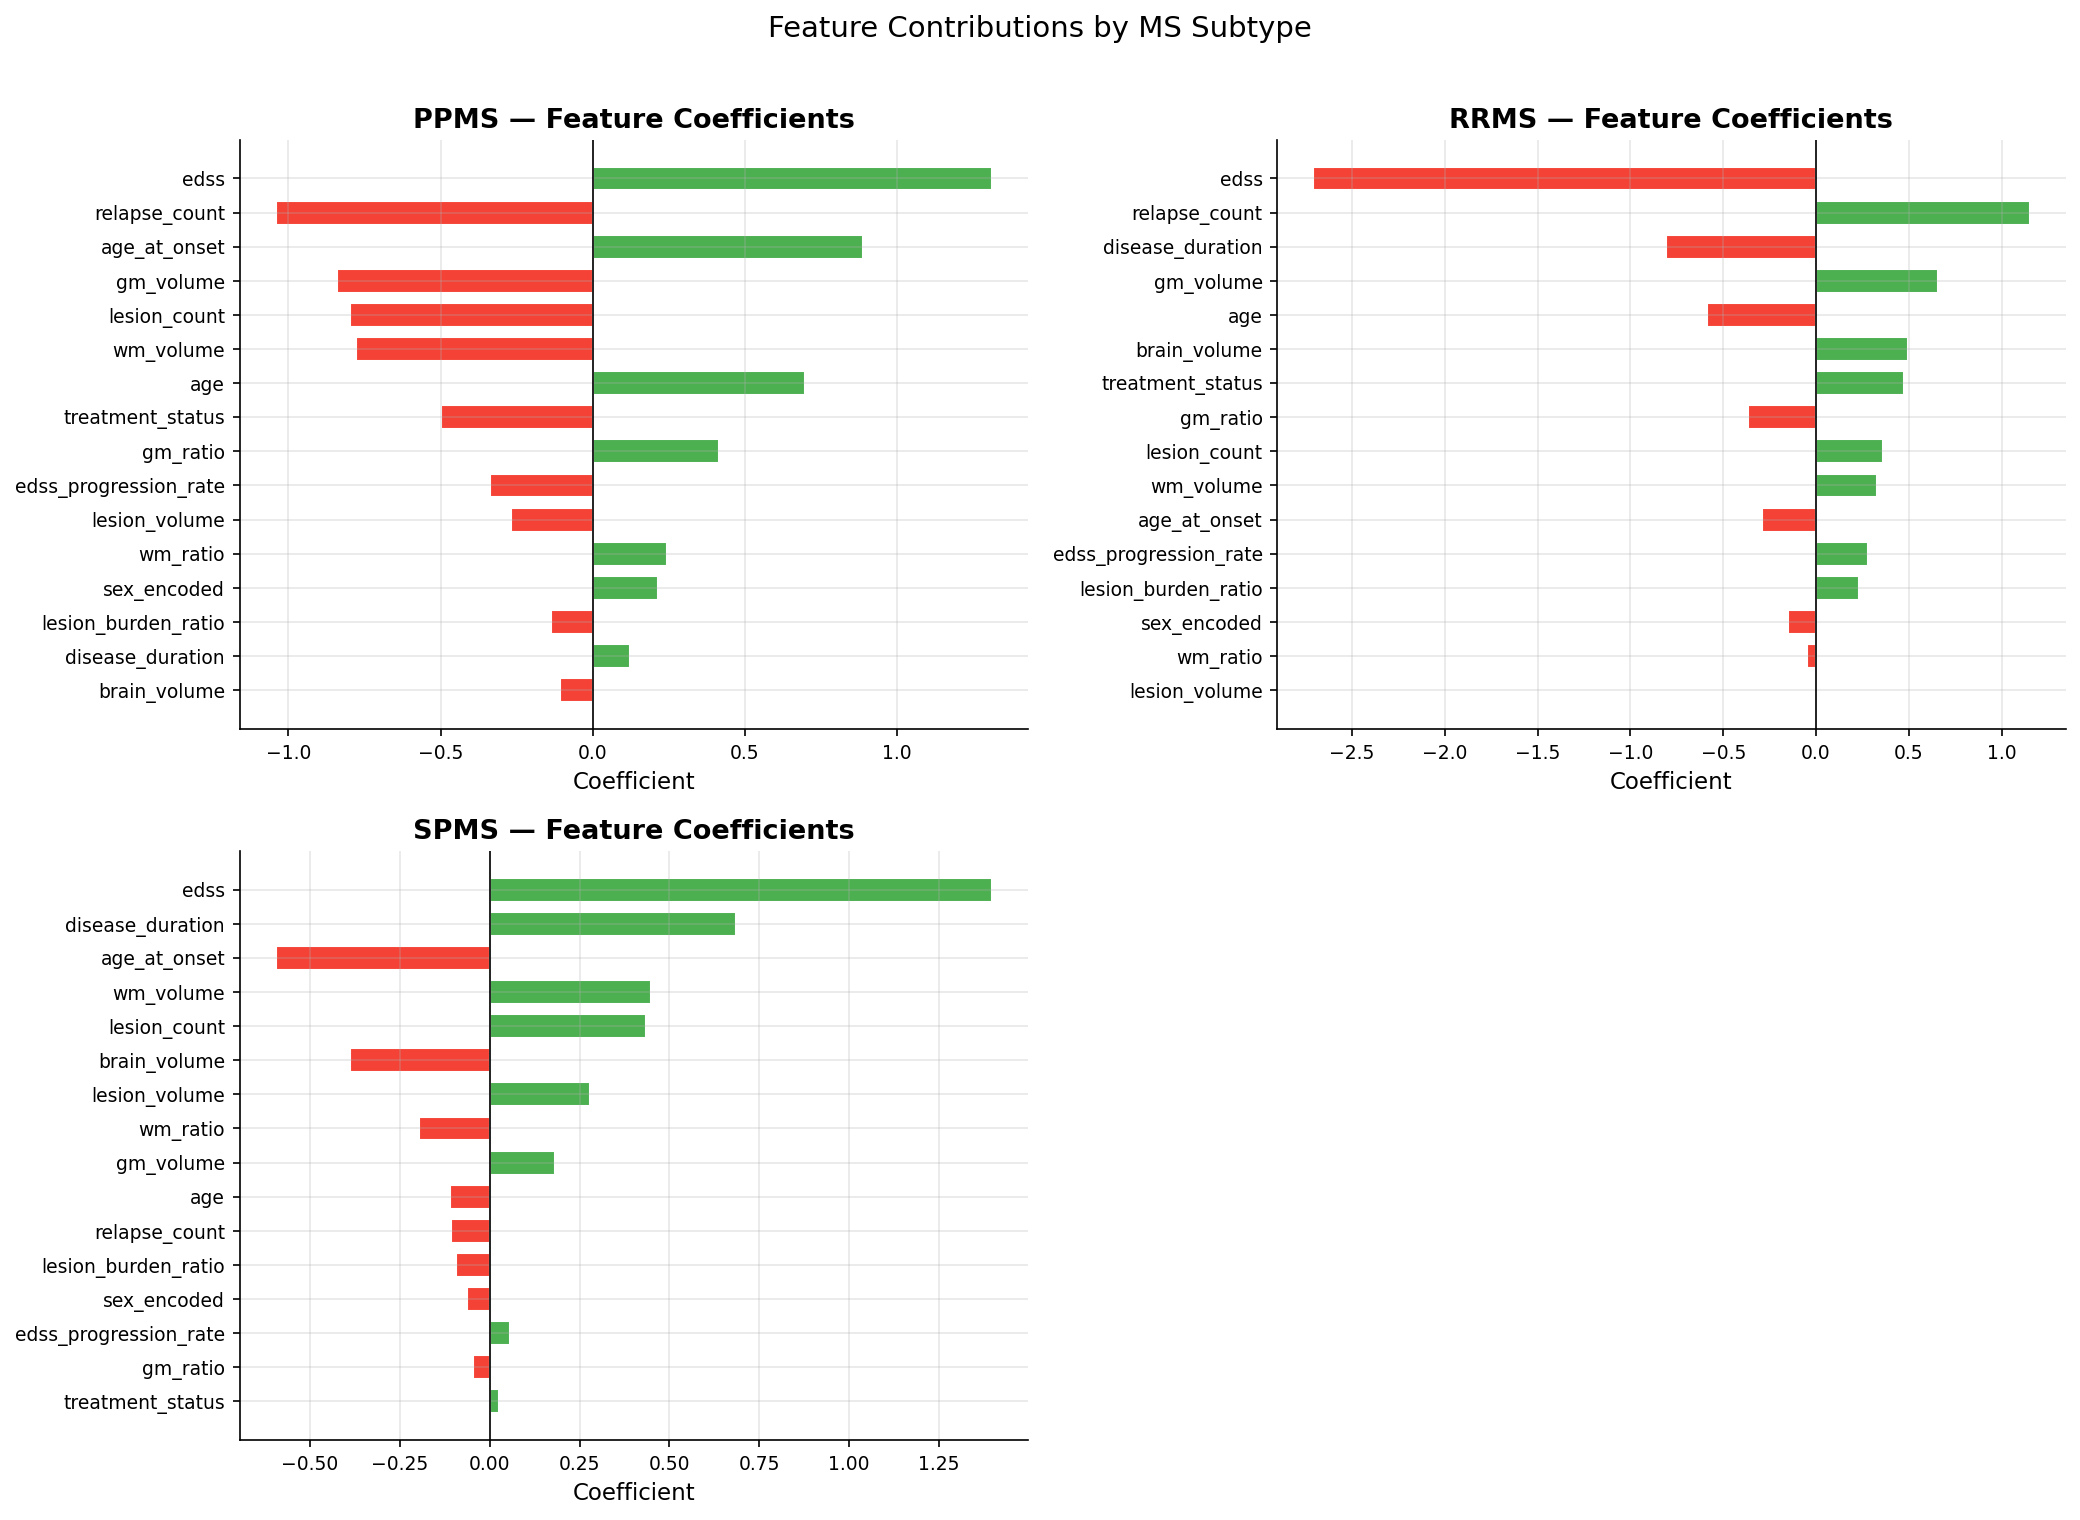

In [27]:
# Top features per class by absolute magnitude
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for idx, name in enumerate(class_names):
    coefs = coef_df.loc[name].sort_values(key=abs, ascending=True)
    colors = ['#4CAF50' if v > 0 else '#F44336' for v in coefs]
    axes[idx].barh(coefs.index, coefs.values, color=colors, edgecolor='white', height=0.7)
    axes[idx].set_title(f'{name} — Feature Coefficients', fontweight='bold')
    axes[idx].axvline(x=0, color='black', linewidth=0.8, linestyle='-')
    axes[idx].set_xlabel('Coefficient')
for j in range(idx+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Feature Contributions by MS Subtype', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

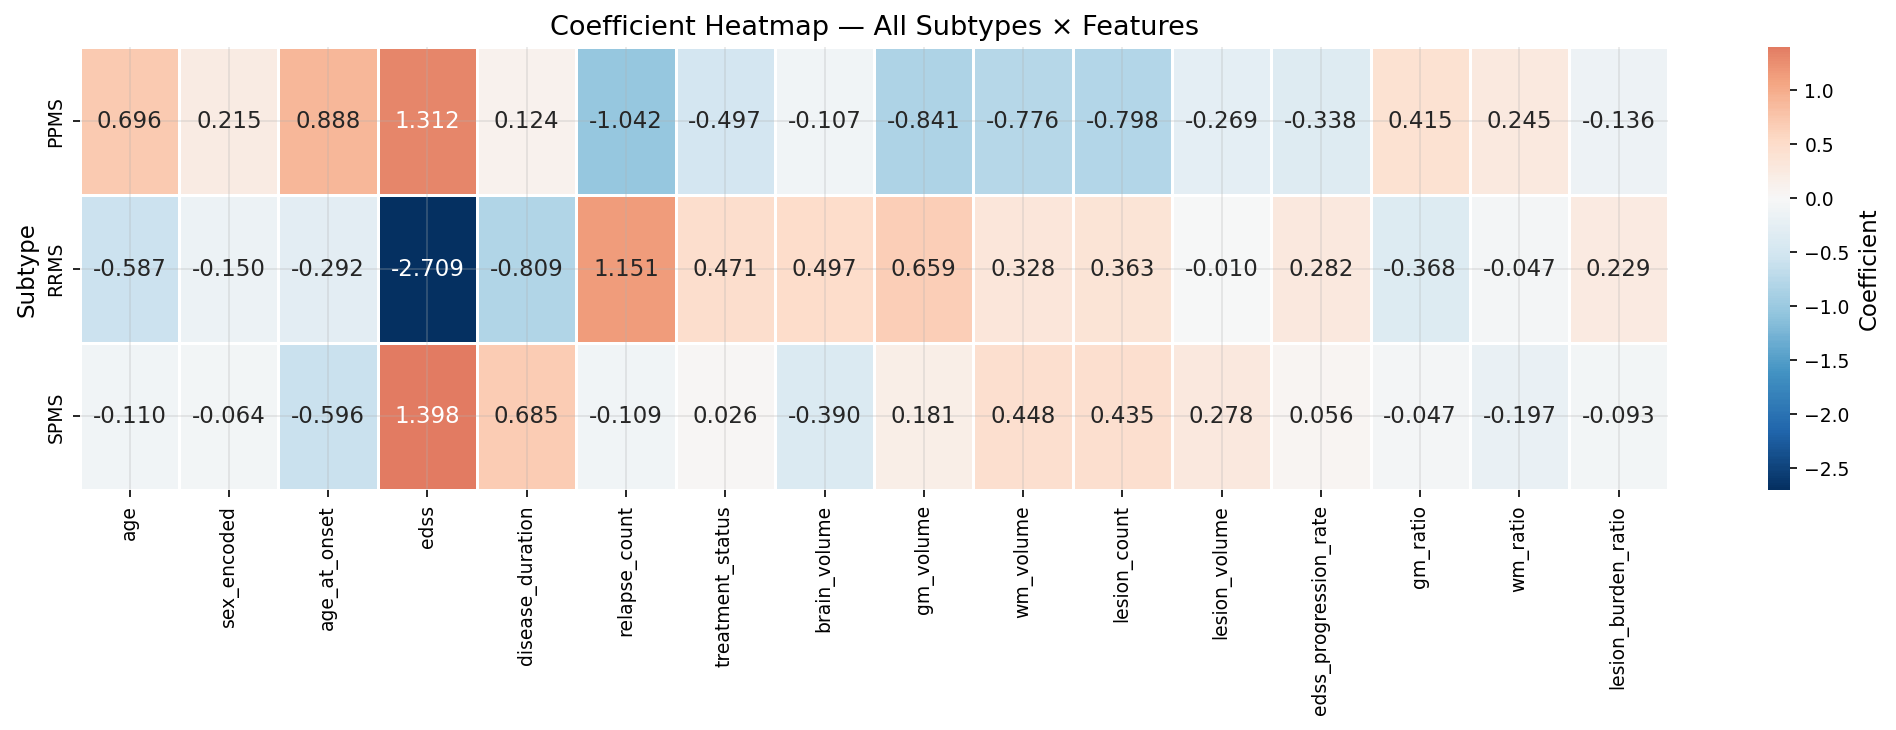

In [28]:
# Heatmap of coefficients
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(coef_df, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Coefficient'})
ax.set_title('Coefficient Heatmap — All Subtypes × Features')
ax.set_ylabel('Subtype')
plt.tight_layout()
plt.show()

---
## 9. Model Diagnostics

### Assumptions of Logistic Regression

1. **Linearity in log-odds:** The log-odds of each class are a linear function of the features.
2. **Independence of observations:** Each patient is an independent sample.
3. **No severe multicollinearity:** Highly correlated features inflate coefficient variance and make interpretation unreliable.

### Variance Inflation Factor (VIF)

VIF quantifies how much the variance of a coefficient is inflated due to collinearity:

$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$

- VIF > 5 → moderate collinearity (warrants investigation)
- VIF > 10 → severe collinearity (consider removing or combining features)

In [29]:
# VIF calculation
vif_data = pd.DataFrame()
vif_data['Feature'] = feature_cols
vif_data['VIF'] = [variance_inflation_factor(X_train_scaled.values, i) for i in range(len(feature_cols))]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print("Variance Inflation Factors:")
print(vif_data.to_string(index=False))
print(f"\nFeatures with VIF > 5: {(vif_data['VIF'] > 5).sum()}")
print(f"Features with VIF > 10: {(vif_data['VIF'] > 10).sum()}")

Variance Inflation Factors:
              Feature       VIF
                  age 81.374214
  lesion_burden_ratio 78.347138
        lesion_volume 75.308394
            gm_volume 64.102056
             wm_ratio 61.717163
             gm_ratio 61.430539
            wm_volume 59.458671
         age_at_onset 58.642702
         brain_volume 43.334865
     disease_duration 23.723454
                 edss  2.069933
        relapse_count  1.355836
edss_progression_rate  1.344835
         lesion_count  1.261191
     treatment_status  1.079143
          sex_encoded  1.056561

Features with VIF > 5: 10
Features with VIF > 10: 10


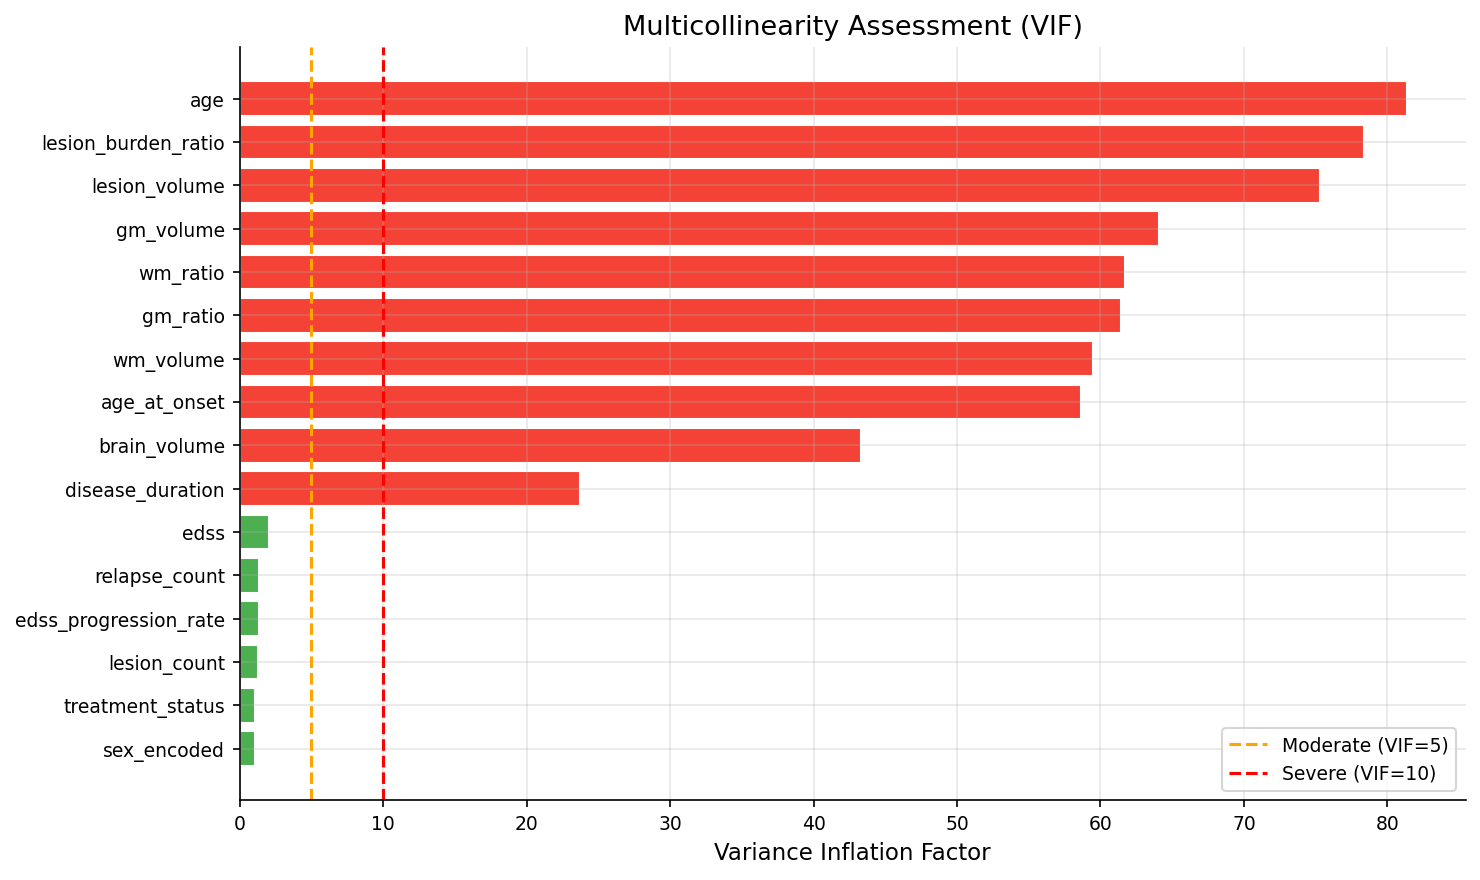

In [30]:
# VIF bar chart
fig, ax = plt.subplots(figsize=(10, 6))
colors_vif = ['#F44336' if v > 10 else '#FF9800' if v > 5 else '#4CAF50' for v in vif_data['VIF']]
ax.barh(vif_data['Feature'][::-1], vif_data['VIF'][::-1], color=colors_vif[::-1], edgecolor='white')
ax.axvline(x=5, color='orange', linestyle='--', linewidth=1.5, label='Moderate (VIF=5)')
ax.axvline(x=10, color='red', linestyle='--', linewidth=1.5, label='Severe (VIF=10)')
ax.set_xlabel('Variance Inflation Factor')
ax.set_title('Multicollinearity Assessment (VIF)')
ax.legend()
plt.tight_layout()
plt.show()

### 9.1 Residual Misclassification Analysis

We examine the predicted probability distributions for correctly and incorrectly classified samples to assess model confidence.

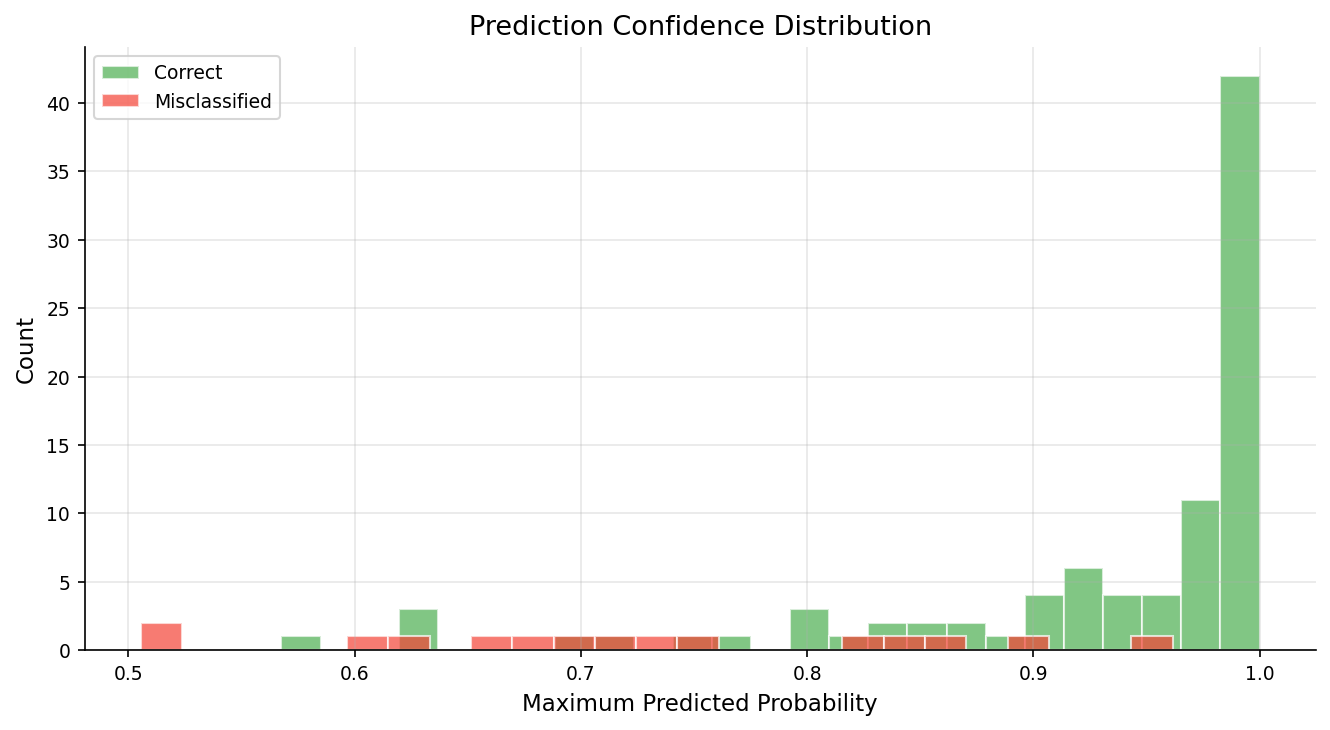

Mean confidence (correct):       0.9319
Mean confidence (misclassified): 0.7254


In [31]:
# Confidence analysis
max_proba = y_proba.max(axis=1)
correct_mask = y_pred == y_test

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(max_proba[correct_mask], bins=25, alpha=0.7, label='Correct', color='#4CAF50', edgecolor='white')
ax.hist(max_proba[~correct_mask], bins=25, alpha=0.7, label='Misclassified', color='#F44336', edgecolor='white')
ax.set_xlabel('Maximum Predicted Probability')
ax.set_ylabel('Count')
ax.set_title('Prediction Confidence Distribution')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean confidence (correct):       {max_proba[correct_mask].mean():.4f}")
if (~correct_mask).sum() > 0:
    print(f"Mean confidence (misclassified): {max_proba[~correct_mask].mean():.4f}")

---
## 10. Model Performance Summary Visualization

A consolidated view of the model's performance across all key metrics and classes.

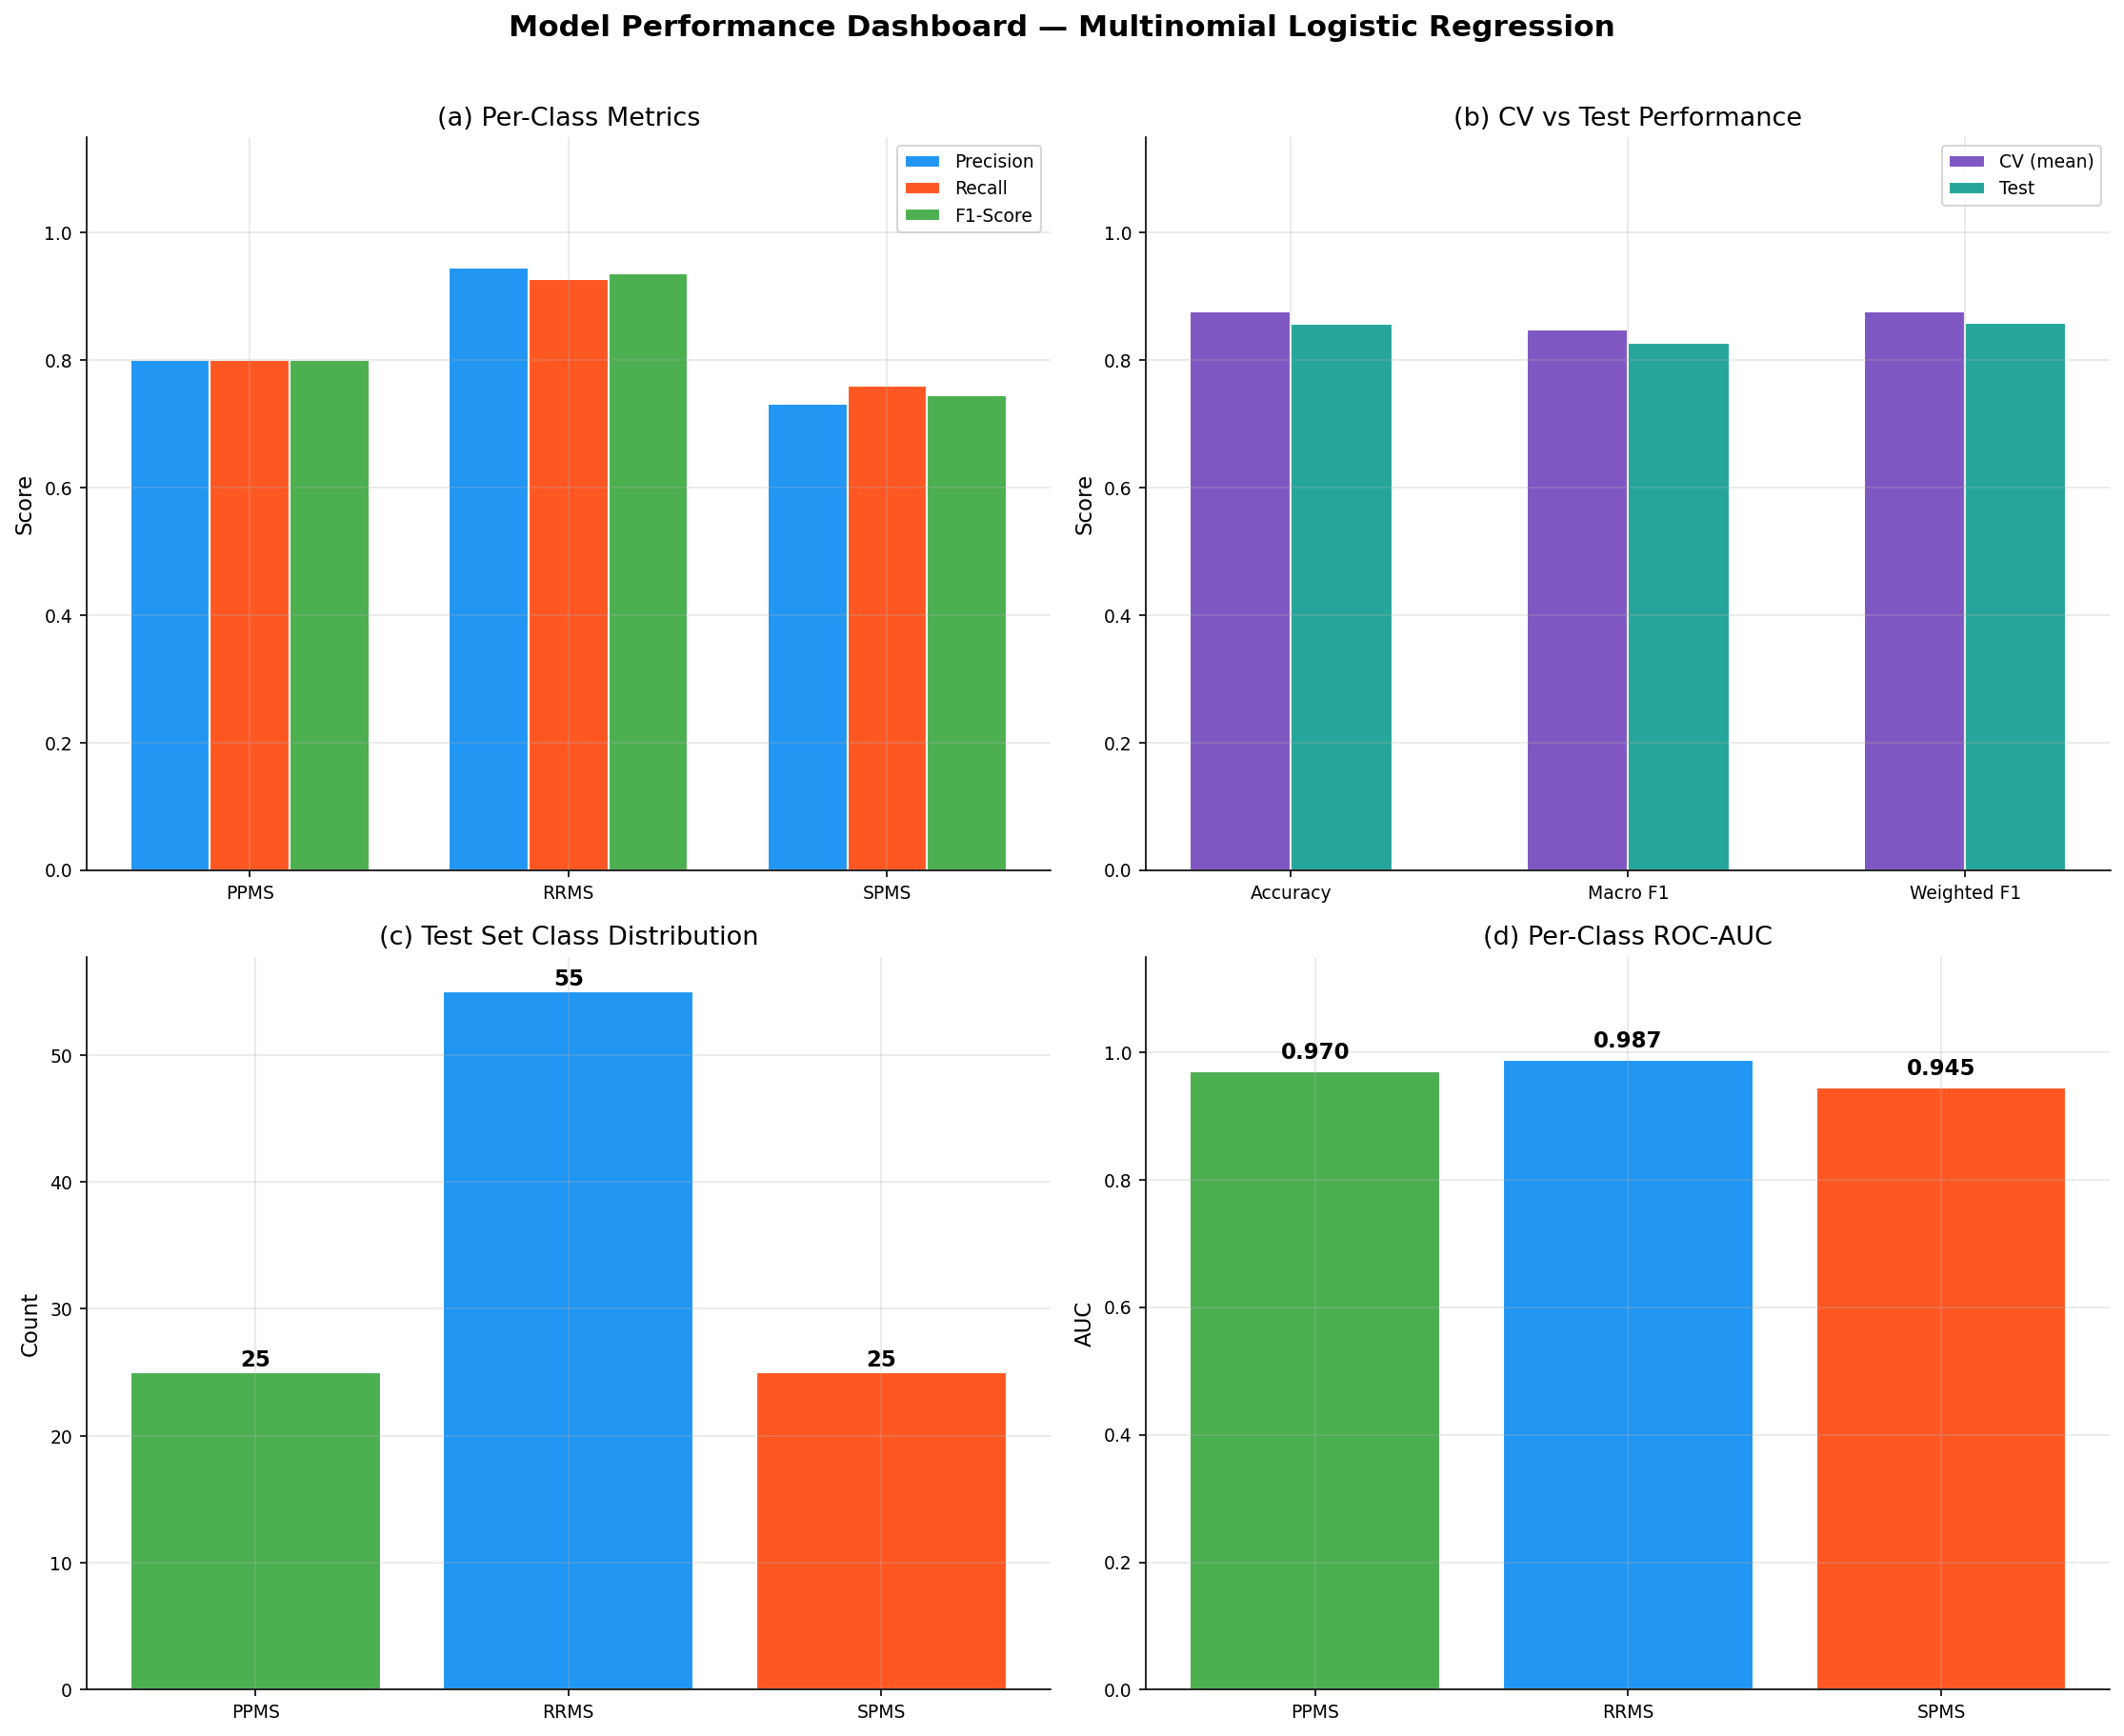

In [32]:
# Comprehensive performance dashboard
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# (a) Per-class precision, recall, F1
prec_per = precision_score(y_test, y_pred, average=None)
rec_per = recall_score(y_test, y_pred, average=None)
f1_per = f1_score(y_test, y_pred, average=None)

x_pos = np.arange(len(class_names))
w = 0.25
axes[0, 0].bar(x_pos - w, prec_per, w, label='Precision', color='#2196F3', edgecolor='white')
axes[0, 0].bar(x_pos, rec_per, w, label='Recall', color='#FF5722', edgecolor='white')
axes[0, 0].bar(x_pos + w, f1_per, w, label='F1-Score', color='#4CAF50', edgecolor='white')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(class_names)
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('(a) Per-Class Metrics')
axes[0, 0].legend()
axes[0, 0].set_ylim(0, 1.15)

# (b) Overall metrics comparison: CV vs Test
cv_means = [cv_results['test_accuracy'].mean(), cv_results['test_f1_macro'].mean(), cv_results['test_f1_weighted'].mean()]
test_vals = [acc, f1_mac, f1_wt]
metric_labels = ['Accuracy', 'Macro F1', 'Weighted F1']
x2 = np.arange(len(metric_labels))
axes[0, 1].bar(x2 - 0.15, cv_means, 0.3, label='CV (mean)', color='#7E57C2', edgecolor='white')
axes[0, 1].bar(x2 + 0.15, test_vals, 0.3, label='Test', color='#26A69A', edgecolor='white')
axes[0, 1].set_xticks(x2)
axes[0, 1].set_xticklabels(metric_labels)
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_title('(b) CV vs Test Performance')
axes[0, 1].legend()
axes[0, 1].set_ylim(0, 1.15)

# (c) Per-class support
support = np.bincount(y_test, minlength=len(class_names))
axes[1, 0].bar(class_names, support, color=[CLASS_PALETTE[n] for n in class_names], edgecolor='white')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('(c) Test Set Class Distribution')
for i, v in enumerate(support):
    axes[1, 0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# (d) Per-class AUC
auc_per_class = []
for i in range(len(class_names)):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    auc_per_class.append(auc(fpr_i, tpr_i))
axes[1, 1].bar(class_names, auc_per_class, color=[CLASS_PALETTE[n] for n in class_names], edgecolor='white')
axes[1, 1].set_ylabel('AUC')
axes[1, 1].set_title('(d) Per-Class ROC-AUC')
axes[1, 1].set_ylim(0, 1.15)
for i, v in enumerate(auc_per_class):
    axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

fig.suptitle('Model Performance Dashboard — Multinomial Logistic Regression', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Summary

This notebook established a **Multinomial Logistic Regression baseline** for MS subtype classification. Key takeaways:

1. **Linear Model Baseline:** Logistic Regression provides an interpretable, well-calibrated baseline against which more complex models (Random Forest, XGBoost, etc.) can be compared.
2. **Coefficient Interpretability:** The model reveals which clinical and MRI features most strongly distinguish each subtype.
3. **Class Imbalance Handling:** Using `class_weight='balanced'` ensures minority subtype (PPMS) are not ignored.
4. **Multicollinearity:** VIF analysis identified correlated features that may benefit from dimensionality reduction in future work.
5. **Limitations:** The linear decision boundary may not capture nonlinear biological interactions inherent in MS pathophysiology.

**Next Steps:** Compare against ensemble methods and explore nonlinear models for improved classification performance.